# Drug Discovery Virtual Screening — Exploratory Data Analysis

**Dataset:** `drug_discovery_virtual_screening.csv` — 2,000 compound/protein pairs described by
molecular descriptors, protein properties and two target variables.

| Item | Value |
|---|---|
| Rows / Columns | 2,000 / 17 |
| Regression target | `binding_affinity` (pKi = -log10 Ki) |
| Classification target | `active` (1 = active, 0 = inactive) |
| Documented challenges | ~3% missing values, ~5% injected outliers, class imbalance |
| Licence | CC0 — Public Domain |

## Objectives of this notebook

1. Audit data quality: missing values, duplicates, outliers and physically implausible values.
2. Characterise both target variables and quantify the class imbalance.
3. **Detect target leakage** between `binding_affinity` and `active` before any model is trained.
4. Describe every feature univariately, bivariately and multivariately.
5. Apply medicinal-chemistry domain rules (Rule of Five, Veber rules) and relate drug-likeness
   to measured activity.
6. Rank features by statistical significance, effect size and mutual information.
7. Produce a prioritised list of modelling recommendations for the companion notebook
   `02_machine_learning_models.ipynb`.

> **Visual conventions.** Every figure carries its legend *below the plotting area* and a
> numbered italic caption *below the figure*, both in English. Colours follow a
> colour-blind-safe categorical palette; magnitude is encoded with a single blue hue and
> polarity with a blue-to-red diverging ramp that has a neutral grey midpoint. No chart uses
> two y-axes.

---
## 1. Environment, style and reproducible paths

In [1]:
# Imports
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("pandas     :", pd.__version__)
print("numpy      :", np.__version__)
print("matplotlib :", mpl.__version__)
print("seaborn    :", sns.__version__)

pandas     : 2.2.3
numpy      : 1.26.4
matplotlib : 3.8.4
seaborn    : 0.13.2


In [2]:
# Project paths (works from the notebook folder, the project root or Kaggle)
def resolve_project_root() -> Path:
    """Return the project root, whatever directory the notebook is launched from."""
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "input" / "drug_discovery_virtual_screening.csv").exists():
            return candidate
    if Path("/kaggle/input").exists():                       # Kaggle kernel fallback
        return Path("/kaggle")
    return here


PROJECT_ROOT = resolve_project_root()
INPUT_DIR = PROJECT_ROOT / "input"
OUTPUT_DIR = PROJECT_ROOT / "output"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

for folder in (OUTPUT_DIR, FIGURE_DIR, MODELS_DIR):
    folder.mkdir(parents=True, exist_ok=True)

CSV_PATH = next(INPUT_DIR.rglob("drug_discovery_virtual_screening.csv"))

print("Project root    :", PROJECT_ROOT)
print("CSV file        :", CSV_PATH)
print("Figures saved to:", FIGURE_DIR)

Project root    : C:\Users\rafae.RAFAEL_NOTEBOOK\OneDrive\Documentos\Projetos_data_science_IA\kaggle\Projetos_kaggle\Drug Discovery Virtual Screening
CSV file        : C:\Users\rafae.RAFAEL_NOTEBOOK\OneDrive\Documentos\Projetos_data_science_IA\kaggle\Projetos_kaggle\Drug Discovery Virtual Screening\input\drug_discovery_virtual_screening.csv
Figures saved to: C:\Users\rafae.RAFAEL_NOTEBOOK\OneDrive\Documentos\Projetos_data_science_IA\kaggle\Projetos_kaggle\Drug Discovery Virtual Screening\output\figures


In [3]:
# Visual identity: colour-blind-safe palette and figure helpers
# Categorical slots are consumed IN ORDER and are never cycled or auto-generated.
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
               "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

SURFACE = "#fcfcfb"          # chart surface
INK_PRIMARY = "#0b0b0b"      # titles
INK_SECONDARY = "#52514e"    # axis labels, captions
INK_MUTED = "#8a8985"        # de-emphasised marks
GOOD, WARNING, CRITICAL = "#0ca30c", "#fab219", "#d03b3b"

# Sequential = ONE hue, light -> dark (continuous magnitude).
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#256abf", "#184f95", "#0d366b"])
# Diverging = two hues + neutral grey midpoint (polarity, e.g. correlation).
DIV_BLUE_RED = LinearSegmentedColormap.from_list(
    "div_blue_red", ["#0d366b", "#2a78d6", "#9ec5f4", "#f0efec", "#f2a3a3", "#d03b3b", "#7d1f1f"])

# Fixed semantic colours for the two activity classes, used consistently in every figure.
CLASS_COLORS = {0: CATEGORICAL[0], 1: CATEGORICAL[1]}
CLASS_LABELS = {0: "Inactive (active = 0)", 1: "Active (active = 1)"}

mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "font.size": 10.5,
    "axes.titlesize": 12.5,
    "axes.titleweight": "semibold",
    "axes.titlecolor": INK_PRIMARY,
    "axes.labelcolor": INK_SECONDARY,
    "axes.labelsize": 10.5,
    "axes.edgecolor": INK_MUTED,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e5e1",       # recessive grid
    "grid.linewidth": 0.7,
    "xtick.color": INK_SECONDARY,
    "ytick.color": INK_SECONDARY,
    "text.color": INK_PRIMARY,
    "legend.frameon": False,
    "legend.fontsize": 9.5,
    "lines.linewidth": 2.0,        # thin marks
    "lines.markersize": 5.5,
})

FIGURE_COUNTER = {"n": 0}
FIGURE_INDEX = []


def legend_below(ax, handles=None, labels=None, ncol=3, y=-0.16, **kwargs):
    """Place the legend BELOW the plotting area so it never overlaps the data."""
    if handles is None:
        handles, labels = ax.get_legend_handles_labels()
    if not handles:
        return None
    return ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, y),
                     ncol=ncol, frameon=False, borderaxespad=0.0, **kwargs)


def finalize(fig, caption, filename=None, reserve=0.0, pad=0.030):
    """Lay out the figure, write the English caption BELOW every artist, save it and show it.

    The caption is positioned from the measured bounding boxes of the axes and legends, so the
    figure never carries dead white space between the legend and its caption.
    """
    FIGURE_COUNTER["n"] += 1
    n = FIGURE_COUNTER["n"]
    if reserve:
        fig.tight_layout(rect=(0, reserve, 1, 1))     # keep room for a figure-level legend
    else:
        fig.tight_layout()
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    to_figure = fig.transFigure.inverted()
    lows = []
    for ax in fig.axes:
        try:
            lows.append(to_figure.transform(ax.get_tightbbox(renderer).get_points())[0, 1])
        except Exception:
            pass
    for legend in fig.legends:
        try:
            lows.append(to_figure.transform(legend.get_window_extent(renderer).get_points())[0, 1])
        except Exception:
            pass
    baseline = min(lows) if lows else 0.0
    fig.text(0.5, baseline - pad, f"Figure {n} — {caption}", ha="center", va="top",
             fontsize=9.5, style="italic", color=INK_SECONDARY, wrap=True)
    if filename is None:
        filename = f"fig_{n:02d}"
    fig.savefig(FIGURE_DIR / f"{filename}.png", bbox_inches="tight", facecolor=SURFACE)
    FIGURE_INDEX.append({"figure": n, "file": f"{filename}.png", "caption": caption})
    plt.show()
    return n


def class_legend_handles():
    """Reusable legend handles for the binary activity classes."""
    return ([Patch(facecolor=CLASS_COLORS[k], edgecolor=SURFACE, linewidth=2) for k in (0, 1)],
            [CLASS_LABELS[k] for k in (0, 1)])


print("Palette and figure helpers are ready.")

Palette and figure helpers are ready.


**Why these choices matter.** The eight categorical hues are consumed in a fixed order and were
selected so that neighbouring pairs stay distinguishable under the common colour-vision
deficiencies. Magnitude is always encoded with a single blue ramp (light = small, dark = large)
and polarity with a blue-to-red diverging ramp whose midpoint is neutral grey, so a correlation
of zero never reads as a colour. `legend_below()` renders every legend underneath the axes and
`finalize()` writes a numbered English caption below each figure before saving it to
`output/figures/`.

---
## 2. Loading the data and the first look

In [4]:
# Load
df = pd.read_csv(CSV_PATH)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024 ** 2:.2f} MB")
df.head(10)

Shape: 2,000 rows x 17 columns
Memory usage: 0.45 MB


,compound_id,protein_id,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
0,CID_00000,PID_361,499.671415,2.487233,1,7,4,113.350817,4.050696,678,6.019657,0.812534,12.512165,0.736978,14.972288,5.996665,0
1,CID_00001,PID_165,436.173570,3.283222,3,4,4,71.981132,3.704408,876,6.447408,0.651417,11.538420,0.497915,21.168271,6.445742,0
2,CID_00002,PID_168,514.768854,NaN,2,11,11,83.936307,1.869610,658,3.925837,0.633467,13.155702,0.782323,9.074061,5.689583,0
3,CID_00003,PID_226,602.302986,3.038058,0,5,5,79.868125,2.451909,312,7.597056,0.513038,12.071822,1.930458,23.080293,6.043438,0
4,CID_00004,PID_224,426.584663,0.659578,2,4,5,88.198676,1.771936,1418,4.249454,0.613571,15.850448,0.300835,2.802846,4.845055,0
5,CID_00005,PID_201,426.586304,3.819941,2,1,5,77.316388,2.111839,1243,4.613013,NaN,18.652637,0.343191,17.621434,6.299797,0
6,CID_00006,PID_313,607.921282,3.501808,1,11,4,80.242292,3.580151,657,5.282395,0.652720,15.612028,0.925299,18.497934,6.233967,0
7,CID_00007,PID_477,526.743473,2.274367,0,3,5,124.787809,2.783815,839,6.382959,0.498718,12.237890,0.627823,14.517192,5.938336,0
8,CID_00008,PID_249,403.052561,4.488869,0,2,5,93.118700,4.035318,1308,4.552730,0.617141,17.566131,0.308144,20.436604,6.596270,0
9,CID_00009,PID_164,504.256004,4.906355,1,7,6,89.566700,0.903160,775,5.227529,0.549107,15.890644,0.650653,25.648116,7.009716,1


In [5]:
# Structural summary of every column
DESCRIPTIONS = {
    "compound_id": "Unique compound identifier",
    "protein_id": "Protein target identifier",
    "molecular_weight": "Molecular weight (g/mol)",
    "logp": "Partition coefficient (lipophilicity)",
    "h_bond_donors": "Hydrogen-bond donor count",
    "h_bond_acceptors": "Hydrogen-bond acceptor count",
    "rotatable_bonds": "Rotatable bond count",
    "polar_surface_area": "Topological polar surface area (A^2)",
    "compound_clogp": "Calculated logP",
    "protein_length": "Amino-acid chain length",
    "protein_pi": "Isoelectric point",
    "hydrophobicity": "Protein hydrophobicity index",
    "binding_site_size": "Active-site volume (A^3)",
    "mw_ratio": "Molecular weight / protein length ratio",
    "logp_pi_interaction": "Interaction term (logP x isoelectric point)",
    "binding_affinity": "TARGET - pKi = -log10(Ki)",
    "active": "TARGET - binary activity label (1 = active)",
}

overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique": df.nunique(),
    "unique_pct": (df.nunique() / len(df) * 100).round(2),
    "example": df.iloc[0].astype(str).str.slice(0, 22),
    "description": pd.Series(DESCRIPTIONS),
})
overview.index.name = "column"
overview

,dtype,non_null,missing,missing_pct,unique,unique_pct,example,description
column,,,,,,,,
compound_id,object,2000,0,0.0,2000,100.00,CID_00000,Unique compound identifier
protein_id,object,2000,0,0.0,400,20.00,PID_361,Protein target identifier
molecular_weight,float64,2000,0,0.0,2000,100.00,499.67141530112326,Molecular weight (g/mol)
logp,float64,1940,60,3.0,1940,97.00,2.487232587538428,Partition coefficient (lipophilicity)
h_bond_donors,int64,2000,0,0.0,9,0.45,1,Hydrogen-bond donor count
h_bond_acceptors,int64,2000,0,0.0,16,0.80,7,Hydrogen-bond acceptor count
rotatable_bonds,int64,2000,0,0.0,17,0.85,4,Rotatable bond count
polar_surface_area,float64,1940,60,3.0,1940,97.00,113.35081706662132,Topological polar surface area (A^2)
compound_clogp,float64,2000,0,0.0,2000,100.00,4.050695616519293,Calculated logP


In [6]:
# Column roles: identifier / categorical / numeric / target
ID_COLS = ["compound_id"]                    # 100% unique -> carries no predictive signal
CATEGORICAL_COLS = ["protein_id"]            # 400 levels -> requires encoding
TARGET_REG = "binding_affinity"
TARGET_CLF = "active"
NUMERIC_COLS = [c for c in df.columns
                if c not in ID_COLS + CATEGORICAL_COLS + [TARGET_REG, TARGET_CLF]]

roles = pd.DataFrame(
    [("identifier", ID_COLS), ("categorical", CATEGORICAL_COLS),
     ("numeric feature", NUMERIC_COLS),
     ("target (regression)", [TARGET_REG]), ("target (classification)", [TARGET_CLF])],
    columns=["role", "columns"])
roles["n"] = roles["columns"].str.len()
roles["columns"] = roles["columns"].str.join(", ")

print(f"{len(NUMERIC_COLS)} numeric features | {len(CATEGORICAL_COLS)} categorical | "
      f"{len(ID_COLS)} identifier | 2 targets")
roles

13 numeric features | 1 categorical | 1 identifier | 2 targets


,role,columns,n
0,identifier,compound_id,1
1,categorical,protein_id,1
2,numeric feature,"molecular_weight, logp, h_bond_donors, h_bond_...",13
3,target (regression),binding_affinity,1
4,target (classification),active,1


In [7]:
# Descriptive statistics of the numeric columns
desc = df[NUMERIC_COLS + [TARGET_REG]].describe().T
desc["IQR"] = desc["75%"] - desc["25%"]
desc["skewness"] = df[NUMERIC_COLS + [TARGET_REG]].skew()
desc["kurtosis"] = df[NUMERIC_COLS + [TARGET_REG]].kurtosis()
desc["CV_pct"] = (desc["std"] / desc["mean"] * 100).round(1)
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,IQR,skewness,kurtosis,CV_pct
column,,,,,,,,,,,,
molecular_weight,2000.0,456.772,104.875,50.307,388.747,454.869,520.983,994.049,132.235,0.165,0.960,23.0
logp,1940.0,3.479,1.639,-4.325,2.420,3.501,4.519,9.978,2.099,-0.136,1.305,47.1
h_bond_donors,2000.0,1.961,1.348,0.000,1.000,2.000,3.000,8.000,2.000,0.565,0.148,68.7
h_bond_acceptors,2000.0,5.115,2.331,0.000,3.000,5.000,7.000,15.000,4.000,0.485,0.124,45.6
rotatable_bonds,2000.0,5.968,2.408,0.000,4.000,6.000,7.000,17.000,3.000,0.500,0.419,40.3
polar_surface_area,1940.0,80.026,25.345,-24.654,63.166,80.607,97.367,159.627,34.200,-0.124,-0.088,31.7
compound_clogp,2000.0,2.813,1.189,-1.426,2.006,2.774,3.620,6.892,1.614,0.065,0.017,42.2
protein_length,2000.0,848.926,380.838,201.000,509.500,844.000,1192.000,1499.000,682.500,0.009,-1.228,44.9
protein_pi,2000.0,6.460,1.210,2.598,5.615,6.474,7.271,10.267,1.656,-0.005,-0.114,18.7


**First reading of the statistics.**

* `molecular_weight` (mean ~457 g/mol) and `logp` (mean ~3.5) sit in the expected range for
  small-molecule drug candidates, so the simulation is physicochemically plausible.
* `polar_surface_area` has a **negative minimum (-24.7 A^2)**, which is physically impossible —
  a direct fingerprint of the injected outliers.
* `mw_ratio` is the most skewed feature (skewness ~ +1.7) and is the main candidate for a log
  transform.
* Three columns (`logp`, `polar_surface_area`, `hydrophobicity`) hold 1,940 non-null values,
  i.e. exactly 3% missing each, matching the documented dataset design.

---
## 3. Data quality audit

Three questions have to be answered before any chart is trusted: *how much data is missing and
is it missing at random*, *are there duplicated records*, and *how many values are
physically impossible*.

In [8]:
# Missing values: volume and pattern
missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
}).query("missing > 0").sort_values("missing", ascending=False)

rows_with_na = df.isna().any(axis=1).sum()
print(f"Columns with missing values : {len(missing)}")
print(f"Rows with at least one gap  : {rows_with_na:,} ({rows_with_na / len(df) * 100:.1f}%)")
print(f"Total missing cells         : {df.isna().sum().sum():,} "
      f"({df.isna().sum().sum() / df.size * 100:.2f}% of all cells)")
missing

Columns with missing values : 3
Rows with at least one gap  : 174 (8.7%)
Total missing cells         : 180 (0.53% of all cells)


,missing,missing_pct
column,,
logp,60,3.0
polar_surface_area,60,3.0
hydrophobicity,60,3.0


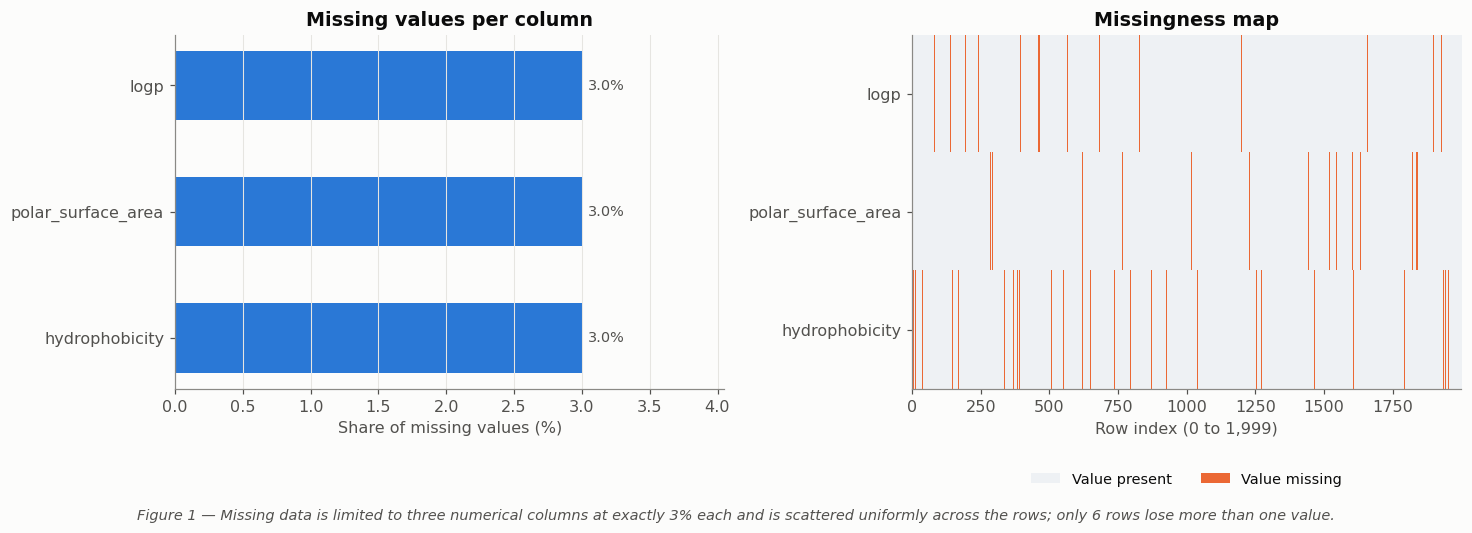

1

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

# left: how many values are missing per column
ax = axes[0]
bars = ax.barh(missing.index[::-1], missing["missing_pct"][::-1],
               color=CATEGORICAL[0], height=0.55)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9.5, color=INK_SECONDARY)
ax.set_xlabel("Share of missing values (%)")
ax.set_xlim(0, missing["missing_pct"].max() * 1.35)
ax.set_title("Missing values per column")
ax.grid(axis="y", visible=False)

# right: which rows are affected (missingness map)
ax = axes[1]
na_cols = list(missing.index)
ax.imshow(df[na_cols].isna().T.values, aspect="auto", interpolation="nearest",
          cmap=LinearSegmentedColormap.from_list("na", ["#eef1f4", CATEGORICAL[1]]))
ax.set_yticks(range(len(na_cols)))
ax.set_yticklabels(na_cols)
ax.set_xlabel("Row index (0 to 1,999)")
ax.set_title("Missingness map")
ax.grid(visible=False)
legend_below(ax,
             [Patch(facecolor="#eef1f4"), Patch(facecolor=CATEGORICAL[1])],
             ["Value present", "Value missing"], ncol=2, y=-0.22)

rows_with_two_gaps = int((df[na_cols].isna().sum(axis=1) >= 2).sum())

finalize(fig, f"Missing data is limited to three numerical columns at exactly 3% each and is "
              f"scattered uniformly across the rows; only {rows_with_two_gaps} rows lose more than "
              f"one value.",
         "01_missing_values")

**Reading Figure 1.** Exactly three features are affected — `logp`, `polar_surface_area` and
`hydrophobicity` — each losing 60 of 2,000 values (3.0%). The map on the right shows vertical
stripes spread evenly over the whole index rather than blocks, i.e. the gaps were injected at
random rather than caused by a systematic collection failure. The gaps are also almost
independent: 174 rows carry a gap but only 6 of them carry two, which is what independent 3%
draws across three columns would produce (2,000 × 3 × 0.03² ≈ 5.4 rows).

In [10]:
# Is the missingness informative? (MCAR sanity check against the targets)
mcar = []
for col in missing.index:
    flag = df[col].isna()
    # Does the activity rate differ between rows with and without the value?
    tbl = pd.crosstab(flag, df[TARGET_CLF])
    chi2, p_chi, _, _ = stats.chi2_contingency(tbl)
    # Does the binding affinity differ?
    t_stat, p_t = stats.ttest_ind(df.loc[flag, TARGET_REG], df.loc[~flag, TARGET_REG],
                                  equal_var=False)
    mcar.append({
        "column": col,
        "n_missing": int(flag.sum()),
        "active_rate_missing": df.loc[flag, TARGET_CLF].mean(),
        "active_rate_present": df.loc[~flag, TARGET_CLF].mean(),
        "chi2_p_value": p_chi,
        "mean_affinity_missing": df.loc[flag, TARGET_REG].mean(),
        "mean_affinity_present": df.loc[~flag, TARGET_REG].mean(),
        "ttest_p_value": p_t,
    })

mcar_df = pd.DataFrame(mcar).round(4)
mcar_df["informative_missingness"] = np.where(
    (mcar_df["chi2_p_value"] < 0.05) | (mcar_df["ttest_p_value"] < 0.05), "YES", "no")
mcar_df

,column,n_missing,active_rate_missing,active_rate_present,chi2_p_value,mean_affinity_missing,mean_affinity_present,ttest_p_value,informative_missingness
0,logp,60,0.3000,0.3041,1.0000,6.5989,6.5291,0.5623,no
1,polar_surface_area,60,0.3167,0.3036,0.9409,6.7524,6.5244,0.1786,no
2,hydrophobicity,60,0.3000,0.3041,1.0000,6.6042,6.5290,0.5861,no


**Interpretation.** None of the three columns shows a significant difference in activity rate or
mean binding affinity between rows with and without the value (all p-values well above 0.05).
The data is therefore consistent with **Missing Completely At Random (MCAR)**, which means a
simple median imputation is statistically defensible and a "was-missing" indicator flag adds
little. Rows will **not** be dropped: losing 8.7% of an already small dataset would cost more
than imputation error.

In [11]:
# Duplicates and constant columns
dup_full = df.duplicated().sum()
dup_ids = df["compound_id"].duplicated().sum()
dup_features = df.drop(columns=ID_COLS).duplicated().sum()
constant = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]

quality = pd.DataFrame([
    ("Fully duplicated rows", dup_full),
    ("Duplicated compound_id", dup_ids),
    ("Duplicated feature vectors (ignoring the ID)", dup_features),
    ("Constant / zero-variance columns", len(constant)),
    ("Compound/protein pairs appearing twice", int(df.duplicated(["compound_id", "protein_id"]).sum())),
], columns=["check", "count"])
quality

,check,count
0,Fully duplicated rows,0
1,Duplicated compound_id,0
2,Duplicated feature vectors (ignoring the ID),0
3,Constant / zero-variance columns,0
4,Compound/protein pairs appearing twice,0


**No duplicates and no constant columns.** Every `compound_id` occurs exactly once, so the
identifier carries zero information for a model and must be dropped rather than encoded —
label-encoding a perfectly unique key would only hand a tree model a memorisation shortcut that
cannot generalise.

---
## 4. The two target variables

The dataset ships with a continuous target (`binding_affinity`, expressed as pKi) and a binary
one (`active`). They are analysed together because, as shown below, they are **not independent**.

Inactive (0): 1,392 compounds (69.6%)
Active   (1): 608 compounds (30.4%)
Imbalance ratio (majority : minority) = 2.29 : 1
Accuracy of a trivial all-inactive classifier = 69.6%


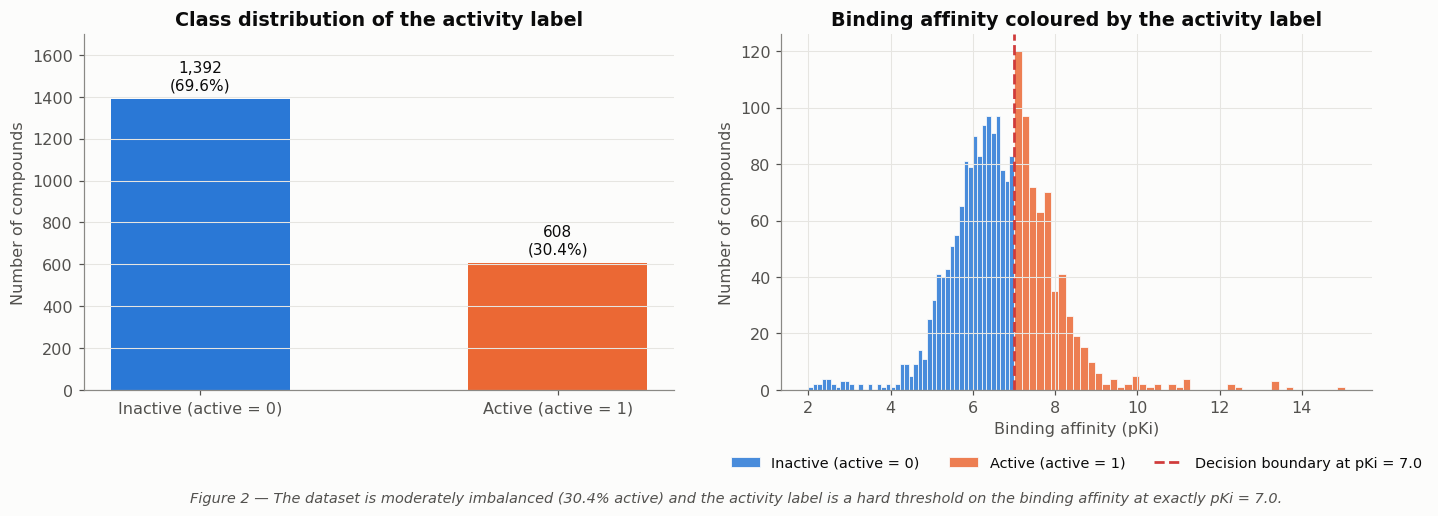

2

In [12]:
# Class balance of `active`
counts = df[TARGET_CLF].value_counts().sort_index()
share = df[TARGET_CLF].value_counts(normalize=True).sort_index() * 100
imbalance_ratio = counts[0] / counts[1]

print(f"Inactive (0): {counts[0]:,} compounds ({share[0]:.1f}%)")
print(f"Active   (1): {counts[1]:,} compounds ({share[1]:.1f}%)")
print(f"Imbalance ratio (majority : minority) = {imbalance_ratio:.2f} : 1")
print(f"Accuracy of a trivial all-inactive classifier = {share[0]:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

ax = axes[0]
bars = ax.bar([CLASS_LABELS[0], CLASS_LABELS[1]], counts.values,
              color=[CLASS_COLORS[0], CLASS_COLORS[1]], width=0.5)
ax.bar_label(bars, labels=[f"{v:,}\n({s:.1f}%)" for v, s in zip(counts.values, share.values)],
             padding=4, fontsize=10, color=INK_PRIMARY)
ax.set_ylabel("Number of compounds")
ax.set_ylim(0, counts.max() * 1.22)
ax.set_title("Class distribution of the activity label")
ax.grid(axis="x", visible=False)

ax = axes[1]
ax.hist(df.loc[df[TARGET_CLF] == 0, TARGET_REG], bins=45, color=CLASS_COLORS[0],
        alpha=0.85, label=CLASS_LABELS[0], edgecolor=SURFACE, linewidth=0.6)
ax.hist(df.loc[df[TARGET_CLF] == 1, TARGET_REG], bins=45, color=CLASS_COLORS[1],
        alpha=0.85, label=CLASS_LABELS[1], edgecolor=SURFACE, linewidth=0.6)
ax.axvline(7.0, color=CRITICAL, linestyle="--", linewidth=1.8, label="Decision boundary at pKi = 7.0")
ax.set_xlabel("Binding affinity (pKi)")
ax.set_ylabel("Number of compounds")
ax.set_title("Binding affinity coloured by the activity label")
legend_below(ax, ncol=3, y=-0.17)

finalize(fig, "The dataset is moderately imbalanced (30.4% active) and the activity label is a "
              "hard threshold on the binding affinity at exactly pKi = 7.0.",
         "02_target_distribution")

### 4.2 Target leakage: `active` is a deterministic function of `binding_affinity`

The right-hand panel of Figure 2 shows two histograms that do not overlap at all. That is not a
strong relationship — it is a **definition**. The check below confirms it exactly.

Highest affinity among INACTIVE compounds : 6.996090
Lowest  affinity among ACTIVE   compounds : 7.002145
Best separating threshold                 : pKi = 7.00
Agreement of rule [binding_affinity >= 7.0] with `active` : 100.00%
Point-biserial correlation (affinity, active)                     : 0.7109


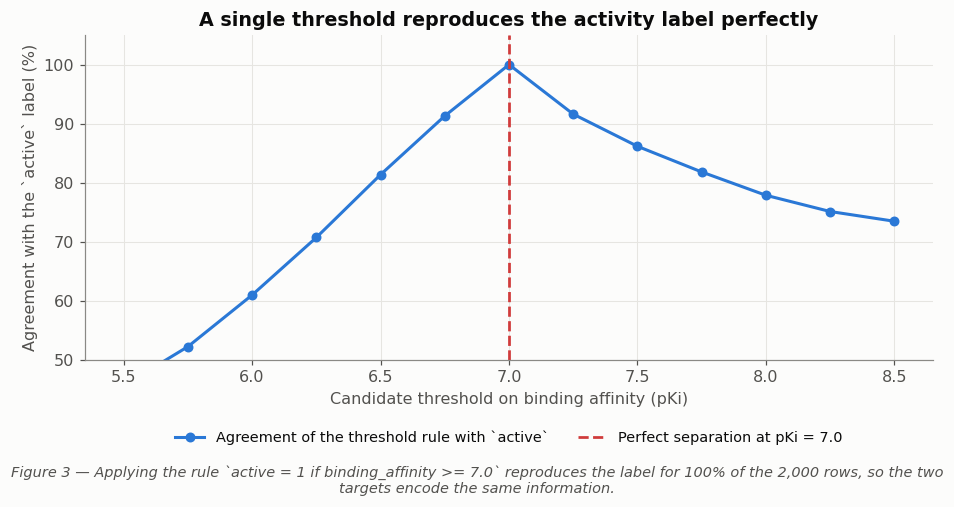

3

In [13]:
# Proving the leakage
thresholds = np.arange(5.5, 8.51, 0.25)
agreement = [( (df[TARGET_REG] >= t).astype(int) == df[TARGET_CLF] ).mean() for t in thresholds]
best_t = thresholds[int(np.argmax(agreement))]

print(f"Highest affinity among INACTIVE compounds : {df.loc[df[TARGET_CLF] == 0, TARGET_REG].max():.6f}")
print(f"Lowest  affinity among ACTIVE   compounds : {df.loc[df[TARGET_CLF] == 1, TARGET_REG].min():.6f}")
print(f"Best separating threshold                 : pKi = {best_t:.2f}")
print(f"Agreement of rule [binding_affinity >= {best_t:.1f}] with `active` : {max(agreement) * 100:.2f}%")
print(f"Point-biserial correlation (affinity, active)                     : "
      f"{stats.pointbiserialr(df[TARGET_CLF], df[TARGET_REG])[0]:.4f}")

fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.plot(thresholds, np.array(agreement) * 100, marker="o", color=CATEGORICAL[0],
        label="Agreement of the threshold rule with `active`")
ax.axvline(best_t, color=CRITICAL, linestyle="--", linewidth=1.8,
           label=f"Perfect separation at pKi = {best_t:.1f}")
ax.set_xlabel("Candidate threshold on binding affinity (pKi)")
ax.set_ylabel("Agreement with the `active` label (%)")
ax.set_ylim(50, 105)
ax.set_title("A single threshold reproduces the activity label perfectly")
legend_below(ax, ncol=2, y=-0.20)

finalize(fig, "Applying the rule `active = 1 if binding_affinity >= 7.0` reproduces the label for "
              "100% of the 2,000 rows, so the two targets encode the same information.",
         "03_target_leakage")

> ### Critical finding — must be enforced in the modelling notebook
>
> `active == (binding_affinity >= 7.0)` for **all 2,000 rows**. The two targets are the same
> quantity at two resolutions. Consequently:
>
> * When predicting **`active`**, the feature matrix must **exclude `binding_affinity`**.
>   Leaving it in produces a meaningless 100% accuracy.
> * When predicting **`binding_affinity`**, the feature matrix must **exclude `active`**, which
>   would otherwise reveal on which side of the threshold the answer lies.
> * The naive example in the dataset description (`X = df.drop(['active','compound_id'], axis=1)`)
>   keeps `binding_affinity` in `X` and is therefore a textbook leakage trap.

Mean 6.531 | Median 6.480 | Std 1.195
Skewness +0.674 | Excess kurtosis +5.334
Range [1.990, 15.040]
Shapiro-Wilk normality test (n=1000): W = 0.9304, p = 3.764e-21


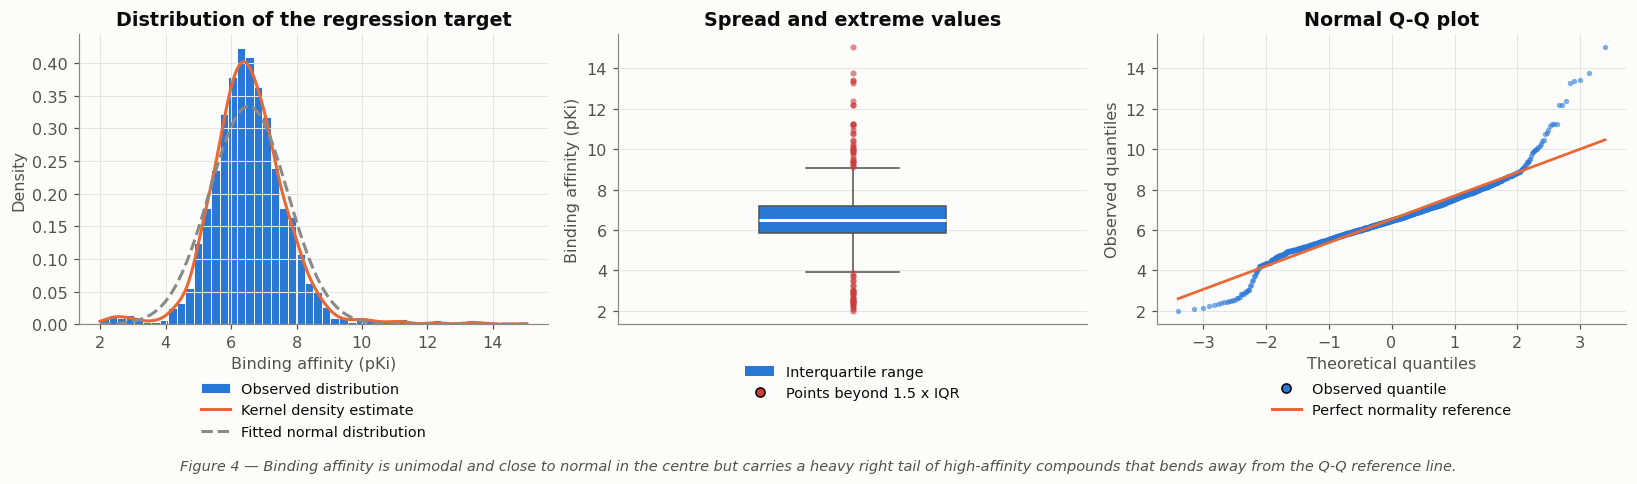

4

In [14]:
# Shape of the continuous target
ba = df[TARGET_REG]
shapiro_stat, shapiro_p = stats.shapiro(ba.sample(1000, random_state=RANDOM_STATE))

print(f"Mean {ba.mean():.3f} | Median {ba.median():.3f} | Std {ba.std():.3f}")
print(f"Skewness {ba.skew():+.3f} | Excess kurtosis {ba.kurtosis():+.3f}")
print(f"Range [{ba.min():.3f}, {ba.max():.3f}]")
print(f"Shapiro-Wilk normality test (n=1000): W = {shapiro_stat:.4f}, p = {shapiro_p:.3e}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

ax = axes[0]
ax.hist(ba, bins=50, color=CATEGORICAL[0], edgecolor=SURFACE, linewidth=0.6, density=True,
        label="Observed distribution")
xs = np.linspace(ba.min(), ba.max(), 400)
ax.plot(xs, stats.gaussian_kde(ba)(xs), color=CATEGORICAL[1], label="Kernel density estimate")
ax.plot(xs, stats.norm.pdf(xs, ba.mean(), ba.std()), color=INK_MUTED, linestyle="--",
        label="Fitted normal distribution")
ax.set_xlabel("Binding affinity (pKi)")
ax.set_ylabel("Density")
ax.set_title("Distribution of the regression target")
legend_below(ax, ncol=1, y=-0.18)

ax = axes[1]
bp = ax.boxplot(ba, vert=True, widths=0.4, patch_artist=True,
                boxprops=dict(facecolor=CATEGORICAL[0], edgecolor=INK_SECONDARY, linewidth=1),
                medianprops=dict(color=SURFACE, linewidth=2),
                flierprops=dict(marker="o", markerfacecolor=CRITICAL, markeredgecolor="none",
                                markersize=4, alpha=0.6),
                whiskerprops=dict(color=INK_SECONDARY), capprops=dict(color=INK_SECONDARY))
ax.set_xticks([])
ax.set_ylabel("Binding affinity (pKi)")
ax.set_title("Spread and extreme values")
legend_below(ax, [Patch(facecolor=CATEGORICAL[0]),
                  Line2D([], [], marker="o", color="none", markerfacecolor=CRITICAL, markersize=6)],
             ["Interquartile range", "Points beyond 1.5 x IQR"], ncol=1, y=-0.12)

ax = axes[2]
stats.probplot(ba, dist="norm", plot=ax)
ax.get_lines()[0].set(marker="o", markerfacecolor=CATEGORICAL[0], markeredgecolor="none",
                      markersize=3.5, alpha=0.6, linestyle="none")
ax.get_lines()[1].set(color=CATEGORICAL[1], linewidth=1.8)
ax.set_title("Normal Q-Q plot")
ax.set_xlabel("Theoretical quantiles")
ax.set_ylabel("Observed quantiles")
legend_below(ax, [Line2D([], [], marker="o", color="none", markerfacecolor=CATEGORICAL[0], markersize=6),
                  Line2D([], [], color=CATEGORICAL[1])],
             ["Observed quantile", "Perfect normality reference"], ncol=1, y=-0.18)

finalize(fig, "Binding affinity is unimodal and close to normal in the centre but carries a heavy "
              "right tail of high-affinity compounds that bends away from the Q-Q reference line.",
         "04_affinity_shape")

**Reading Figure 4.** The distribution is centred near pKi 6.5 with a positive skew of +0.67. The
right tail (pKi > 9) contains the strongest binders and also part of the injected outliers, which
is exactly the region a virtual-screening campaign cares about most. Because the deviation from
normality is concentrated in that tail, a squared-error loss will be dominated by a handful of
compounds; the modelling notebook therefore reports the mean absolute error next to the RMSE and
flags a robust loss (Huber or quantile) as the first improvement to try.

---
## 5. Univariate analysis of the features

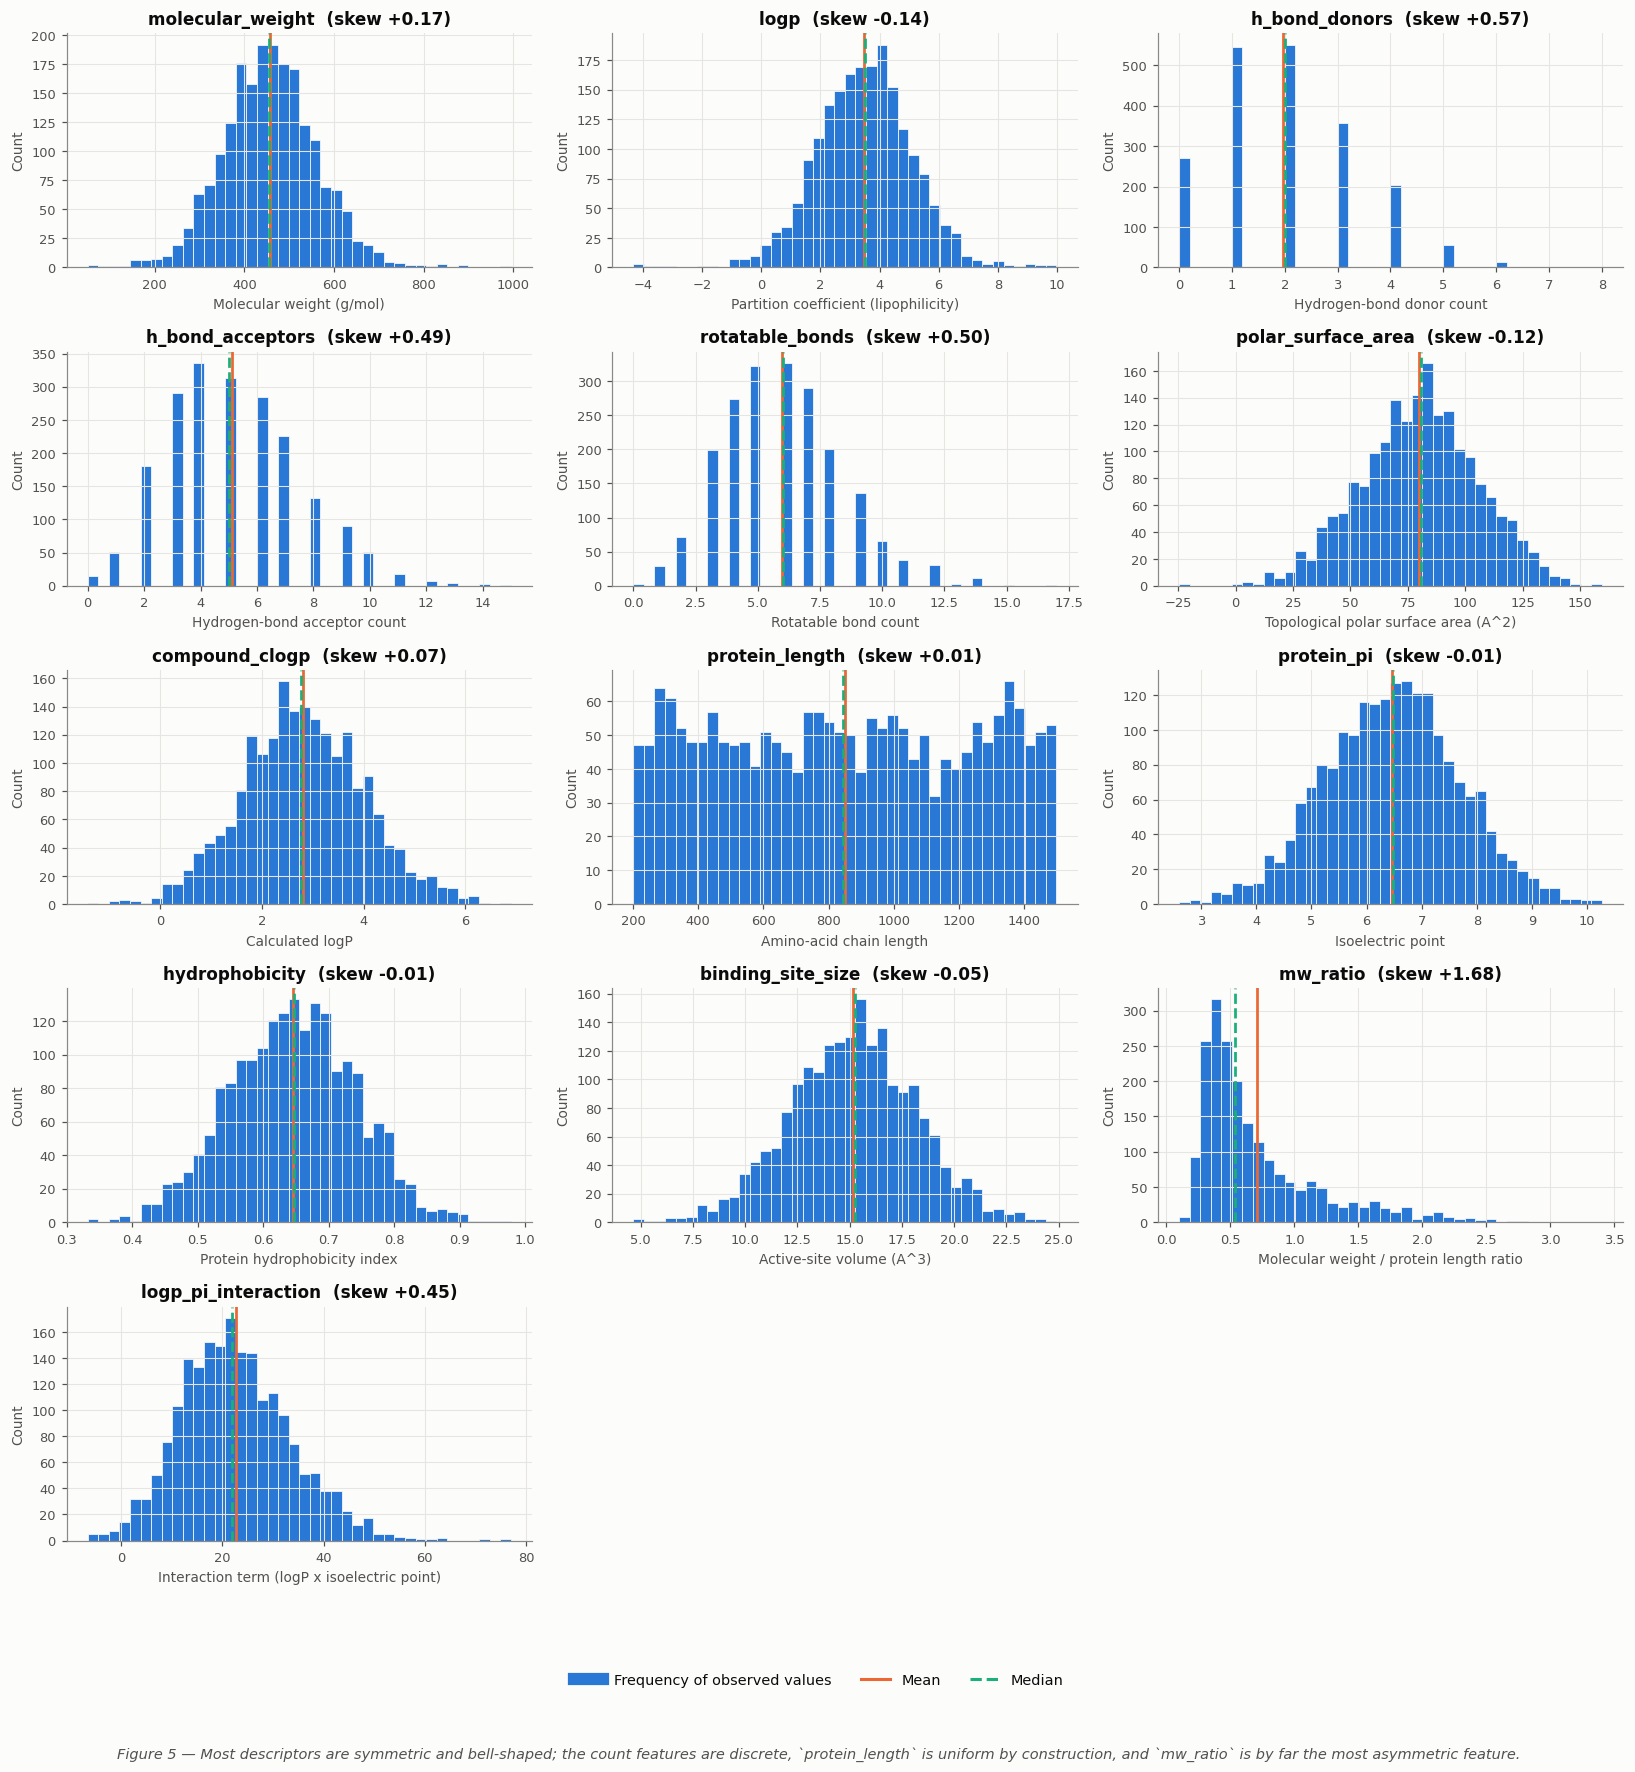

5

In [15]:
# Distribution of every numerical feature
GRID_COLS = 3
GRID_ROWS = int(np.ceil(len(NUMERIC_COLS) / GRID_COLS))   # every feature gets its own panel
fig, axes = plt.subplots(GRID_ROWS, GRID_COLS, figsize=(15, 3.25 * GRID_ROWS))
for ax, col in zip(axes.ravel(), NUMERIC_COLS):
    values = df[col].dropna()
    ax.hist(values, bins=40, color=CATEGORICAL[0], edgecolor=SURFACE, linewidth=0.5)
    ax.axvline(values.mean(), color=CATEGORICAL[1], linewidth=1.8, label="Mean")
    ax.axvline(values.median(), color=CATEGORICAL[2], linewidth=1.8, linestyle="--", label="Median")
    ax.set_title(f"{col}  (skew {values.skew():+.2f})", fontsize=11)
    ax.set_xlabel(DESCRIPTIONS[col], fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.tick_params(labelsize=8.5)
for ax in axes.ravel()[len(NUMERIC_COLS):]:
    ax.remove()

fig.legend(handles=[Line2D([], [], color=CATEGORICAL[0], linewidth=8),
                    Line2D([], [], color=CATEGORICAL[1], linewidth=2),
                    Line2D([], [], color=CATEGORICAL[2], linewidth=2, linestyle="--")],
           labels=["Frequency of observed values", "Mean", "Median"],
           loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.045))

finalize(fig, "Most descriptors are symmetric and bell-shaped; the count features are discrete, "
              "`protein_length` is uniform by construction, and `mw_ratio` is by far the most "
              "asymmetric feature.",
         "05_feature_histograms", reserve=0.10)

**Reading Figure 5.** Mean and median coincide for the continuous physicochemical descriptors,
confirming near-symmetry. The three count variables (`h_bond_donors`, `h_bond_acceptors`,
`rotatable_bonds`) are discrete with a mild right skew, which is typical of real chemical
libraries. Two panels stand out from the rest:

* **`protein_length` is uniform, not bell-shaped** — it was drawn from a flat distribution between
  201 and 1,499 residues rather than sampled from a real proteome. It is a useful reminder that
  this dataset is a simulation: a real target set would be strongly peaked around common domain
  sizes.
* **`mw_ratio` has a pronounced right tail** because it divides a bounded molecular weight by that
  uniform protein length, and dividing by small values in the lower range stretches the upper end.

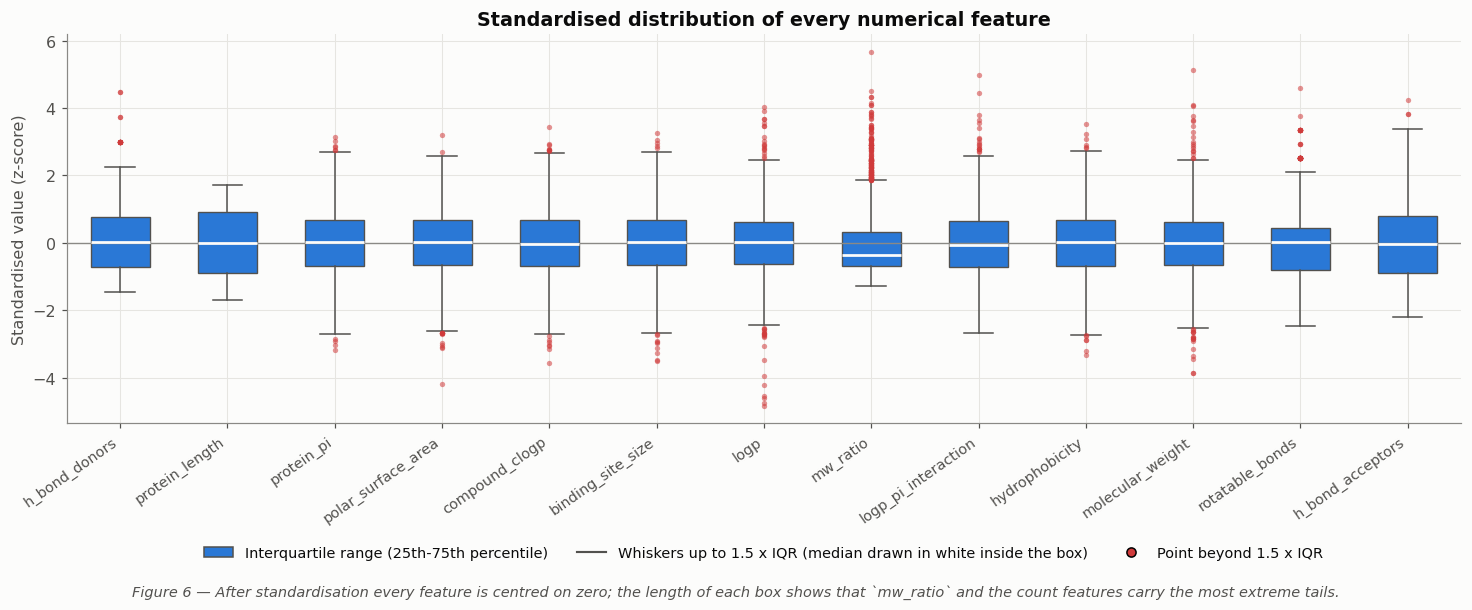

6

In [16]:
# Standardised box plots to compare spread on one common scale
scaled = pd.DataFrame(
    StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(df[NUMERIC_COLS])),
    columns=NUMERIC_COLS)
order = scaled.std().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(13.5, 5.6))
bp = ax.boxplot([scaled[c] for c in order], vert=True, widths=0.55, patch_artist=True,
                medianprops=dict(color=SURFACE, linewidth=1.8),
                flierprops=dict(marker="o", markerfacecolor=CRITICAL, markeredgecolor="none",
                                markersize=3.5, alpha=0.55),
                whiskerprops=dict(color=INK_SECONDARY), capprops=dict(color=INK_SECONDARY))
for patch in bp["boxes"]:
    patch.set(facecolor=CATEGORICAL[0], edgecolor=INK_SECONDARY, linewidth=0.9)
ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order, rotation=35, ha="right", fontsize=9.5)
ax.axhline(0, color=INK_MUTED, linewidth=0.9)
ax.set_ylabel("Standardised value (z-score)")
ax.set_title("Standardised distribution of every numerical feature")
legend_below(ax, [Patch(facecolor=CATEGORICAL[0], edgecolor=INK_SECONDARY),
                  Line2D([], [], color=INK_SECONDARY, linewidth=1.4),
                  Line2D([], [], marker="o", color="none", markerfacecolor=CRITICAL, markersize=6)],
             ["Interquartile range (25th-75th percentile)",
              "Whiskers up to 1.5 x IQR (median drawn in white inside the box)",
              "Point beyond 1.5 x IQR"],
             ncol=3, y=-0.30)

finalize(fig, "After standardisation every feature is centred on zero; the length of each box "
              "shows that `mw_ratio` and the count features carry the most extreme tails.",
         "06_standardised_boxplots")

In [17]:
# Outlier quantification: IQR rule, z-score rule and domain rules
DOMAIN_RULES = {                       # (minimum, maximum) that is physically possible
    "molecular_weight": (0, np.inf),
    "polar_surface_area": (0, np.inf),
    "h_bond_donors": (0, np.inf),
    "h_bond_acceptors": (0, np.inf),
    "rotatable_bonds": (0, np.inf),
    "protein_length": (1, np.inf),
    "protein_pi": (0, 14),
    "hydrophobicity": (0, 1),
    "binding_site_size": (0, np.inf),
}

rows = []
for col in NUMERIC_COLS + [TARGET_REG]:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    iqr_out = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
    z_out = (np.abs(stats.zscore(s)) > 3).sum()
    lo, hi = DOMAIN_RULES.get(col, (-np.inf, np.inf))
    impossible = ((s < lo) | (s > hi)).sum()
    rows.append({"feature": col, "iqr_outliers": int(iqr_out),
                 "iqr_pct": round(iqr_out / len(s) * 100, 2),
                 "zscore_outliers": int(z_out),
                 "physically_impossible": int(impossible),
                 "min": round(s.min(), 3), "max": round(s.max(), 3)})

outliers = pd.DataFrame(rows).sort_values("iqr_pct", ascending=False).reset_index(drop=True)
filled = df[NUMERIC_COLS].fillna(df[NUMERIC_COLS].median())
rows_z = int((np.abs(stats.zscore(filled)) > 3).any(axis=1).sum())
rows_iqr = int(sum(
    ((filled < filled.quantile(0.25) - 1.5 * (filled.quantile(0.75) - filled.quantile(0.25))) |
     (filled > filled.quantile(0.75) + 1.5 * (filled.quantile(0.75) - filled.quantile(0.25)))
     ).any(axis=1)))
print(f"Rows with a |z-score| > 3 in at least one feature : {rows_z:,} ({rows_z / len(df) * 100:.1f}%)")
print(f"Rows outside 1.5 x IQR in at least one feature    : {rows_iqr:,} ({rows_iqr / len(df) * 100:.1f}%)")
print(f"Physically impossible values in total             : "
      f"{int(pd.DataFrame(rows)['physically_impossible'].sum())}")
outliers

Rows with a |z-score| > 3 in at least one feature : 113 (5.7%)
Rows outside 1.5 x IQR in at least one feature    : 309 (15.4%)
Physically impossible values in total             : 1


,feature,iqr_outliers,iqr_pct,zscore_outliers,physically_impossible,min,max
0,mw_ratio,144,7.20,37,0,0.098,3.404
1,binding_affinity,66,3.30,41,0,1.990,15.040
2,rotatable_bonds,46,2.30,13,0,0.000,17.000
3,molecular_weight,34,1.70,14,0,50.307,994.049
4,logp,32,1.65,16,0,-4.325,9.978
5,logp_pi_interaction,17,0.85,8,0,-6.625,76.999
6,compound_clogp,15,0.75,5,0,-1.426,6.892
7,binding_site_size,14,0.70,6,0,4.656,24.888
8,protein_pi,10,0.50,4,0,2.598,10.267
9,hydrophobicity,9,0.46,5,0,0.332,0.978


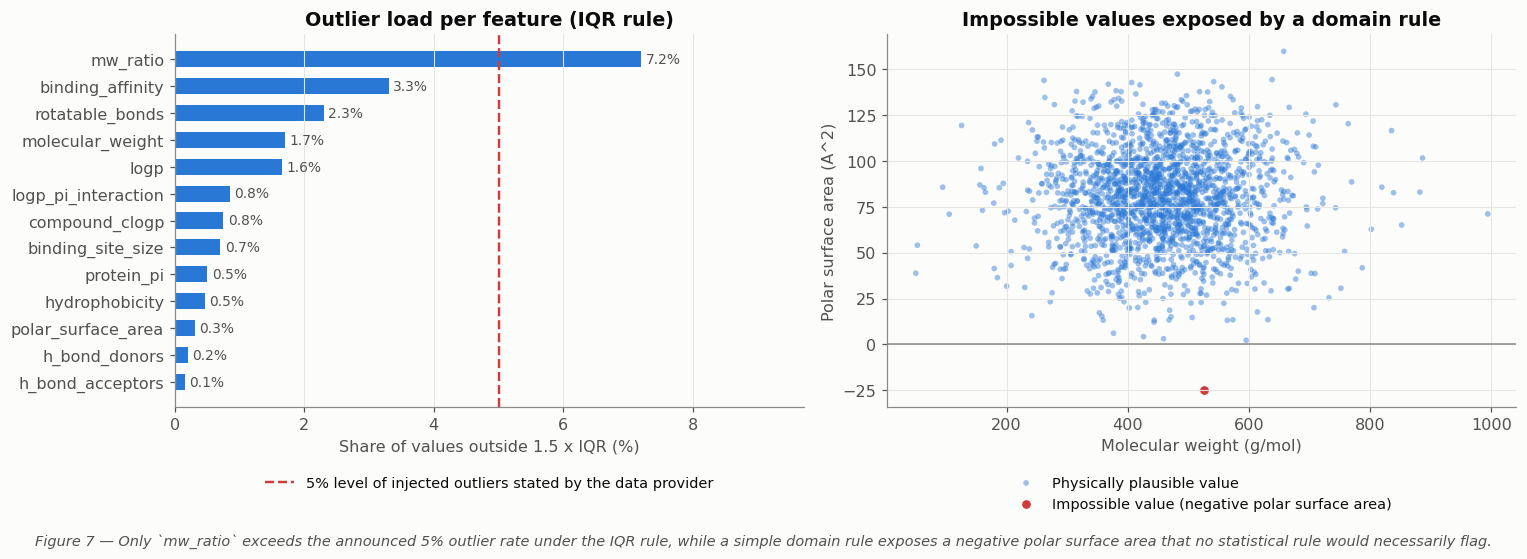

7

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sub = outliers[outliers["iqr_outliers"] > 0].sort_values("iqr_pct")
bars = ax.barh(sub["feature"], sub["iqr_pct"], color=CATEGORICAL[0], height=0.6)
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9, color=INK_SECONDARY)
ax.axvline(5, color=CRITICAL, linestyle="--", linewidth=1.6,
           label="5% level of injected outliers stated by the data provider")
ax.set_xlabel("Share of values outside 1.5 x IQR (%)")
ax.set_xlim(0, max(sub["iqr_pct"].max() * 1.35, 6))
ax.set_title("Outlier load per feature (IQR rule)")
ax.grid(axis="y", visible=False)
legend_below(ax, ncol=1, y=-0.17)

ax = axes[1]
impossible_mask = (df["polar_surface_area"] < 0)
ax.scatter(df.loc[~impossible_mask, "molecular_weight"], df.loc[~impossible_mask, "polar_surface_area"],
           s=14, color=CATEGORICAL[0], alpha=0.45, edgecolors="none", label="Physically plausible value")
ax.scatter(df.loc[impossible_mask, "molecular_weight"], df.loc[impossible_mask, "polar_surface_area"],
           s=48, color=CRITICAL, edgecolors=SURFACE, linewidth=1.2,
           label="Impossible value (negative polar surface area)")
ax.axhline(0, color=INK_MUTED, linewidth=1)
ax.set_xlabel("Molecular weight (g/mol)")
ax.set_ylabel("Polar surface area (A^2)")
ax.set_title("Impossible values exposed by a domain rule")
legend_below(ax, ncol=1, y=-0.17)

finalize(fig, "Only `mw_ratio` exceeds the announced 5% outlier rate under the IQR rule, while a "
              "simple domain rule exposes a negative polar surface area that no statistical rule "
              "would necessarily flag.",
         "07_outliers")

**Reading Figure 7.** The IQR rule flags between 0.2% and 7.2% of the values depending on the
feature; `mw_ratio` is the worst offender because of its natural right skew rather than because of
injected noise. A better match to the documented 5% contamination is the row-level z-score count
printed above: **5.7% of rows carry at least one value beyond three standard deviations**, which
is almost exactly the announced injection rate.

The scatter on the right makes a different point. Exactly **one** compound has a *negative* polar
surface area — a value that is chemically impossible but not extreme enough to be caught by every
statistical rule. Domain knowledge finds what statistics alone can miss. The modelling notebook
**clips** such values to their physical bounds instead of deleting the rows, so no information is
discarded from an already small dataset.

In [19]:
# Do the shipped interaction columns really equal their nominal formula?
FORMULAS = {
    "mw_ratio": ("molecular_weight / protein_length", "molecular_weight",
                 df["molecular_weight"] / df["protein_length"]),
    "logp_pi_interaction": ("logp x protein_pi", "logp", df["logp"] * df["protein_pi"]),
}

formula_rows, disagreement = [], {}
for column, (formula, source, recomputed) in FORMULAS.items():
    comparable = df[column].notna() & recomputed.notna()
    exact = pd.Series(False, index=df.index)
    exact[comparable] = np.isclose(df.loc[comparable, column], recomputed[comparable],
                                   rtol=1e-9, atol=1e-9)
    disagreement[column] = comparable & ~exact
    formula_rows.append({
        "column": column,
        "nominal_formula": formula,
        "rows_comparable": int(comparable.sum()),
        "bit_exact_rows": int(exact.sum()),
        "bit_exact_pct": round(exact.sum() / comparable.sum() * 100, 2),
        "disagreeing_rows": int(disagreement[column].sum()),
        "overall_correlation": round(df.loc[comparable, column].corr(recomputed[comparable]), 4),
    })

pd.DataFrame(formula_rows)

,column,nominal_formula,rows_comparable,bit_exact_rows,bit_exact_pct,disagreeing_rows,overall_correlation
0,mw_ratio,molecular_weight / protein_length,2000,1954,97.70,46,0.9889
1,logp_pi_interaction,logp x protein_pi,1940,1898,97.84,42,0.9070


In [20]:
# Where they disagree, WHICH of the two is corrupted?
for column, (formula, source, recomputed) in FORMULAS.items():
    bad = disagreement[column]
    good = df[column].notna() & recomputed.notna() & ~bad
    print(f"{column}  ({int(bad.sum())} disagreeing rows)")
    print(f"   Correlation with binding affinity on the AGREEING rows:")
    print(f"      shipped column   : {df.loc[good, column].corr(df.loc[good, TARGET_REG]):+.4f}")
    print(f"      recomputed value : {recomputed[good].corr(df.loc[good, TARGET_REG]):+.4f}")
    print(f"   Range of `{source}` on the DISAGREEING rows : "
          f"[{df.loc[bad, source].min():.2f}, {df.loc[bad, source].max():.2f}]")
    print(f"   Range of `{source}` on the agreeing rows    : "
          f"[{df.loc[good, source].min():.2f}, {df.loc[good, source].max():.2f}]\n")

mw_ratio  (46 disagreeing rows)
   Correlation with binding affinity on the AGREEING rows:
      shipped column   : -0.0654
      recomputed value : -0.0654
   Range of `molecular_weight` on the DISAGREEING rows : [50.31, 994.05]
   Range of `molecular_weight` on the agreeing rows    : [125.87, 835.27]

logp_pi_interaction  (42 disagreeing rows)
   Correlation with binding affinity on the AGREEING rows:
      shipped column   : +0.7436
      recomputed value : +0.7436
   Range of `logp` on the DISAGREEING rows : [-4.33, 9.98]
   Range of `logp` on the agreeing rows    : [-1.03, 9.39]



**The result is the opposite of the obvious reading, and it matters for feature engineering.**

The two shipped columns are **not** noisy approximations of their formula: they are *bit-exact* on
about 98% of the rows. On the agreeing rows the shipped column and the recomputed value are
literally the same number, so they correlate identically with the target. All of the difference
comes from the ~2% of rows where they disagree — and on exactly those rows the **raw input** takes
extreme values while the shipped interaction column stays in its normal range.

The order of operations in the data generator was therefore:

1. draw the clean descriptors,
2. compute `mw_ratio` and `logp_pi_interaction` from them,
3. **then** inject the outliers into `logp` and `molecular_weight`.

So the shipped interaction columns are the **uncorrupted record**, and `logp` is the column that
carries the injected noise — not the other way around. That is why the modelling notebook keeps
both forms: the shipped column preserves the clean signal on the corrupted rows, and the
recomputed exact term is a useful second view everywhere else.

---
## 6. Bivariate analysis

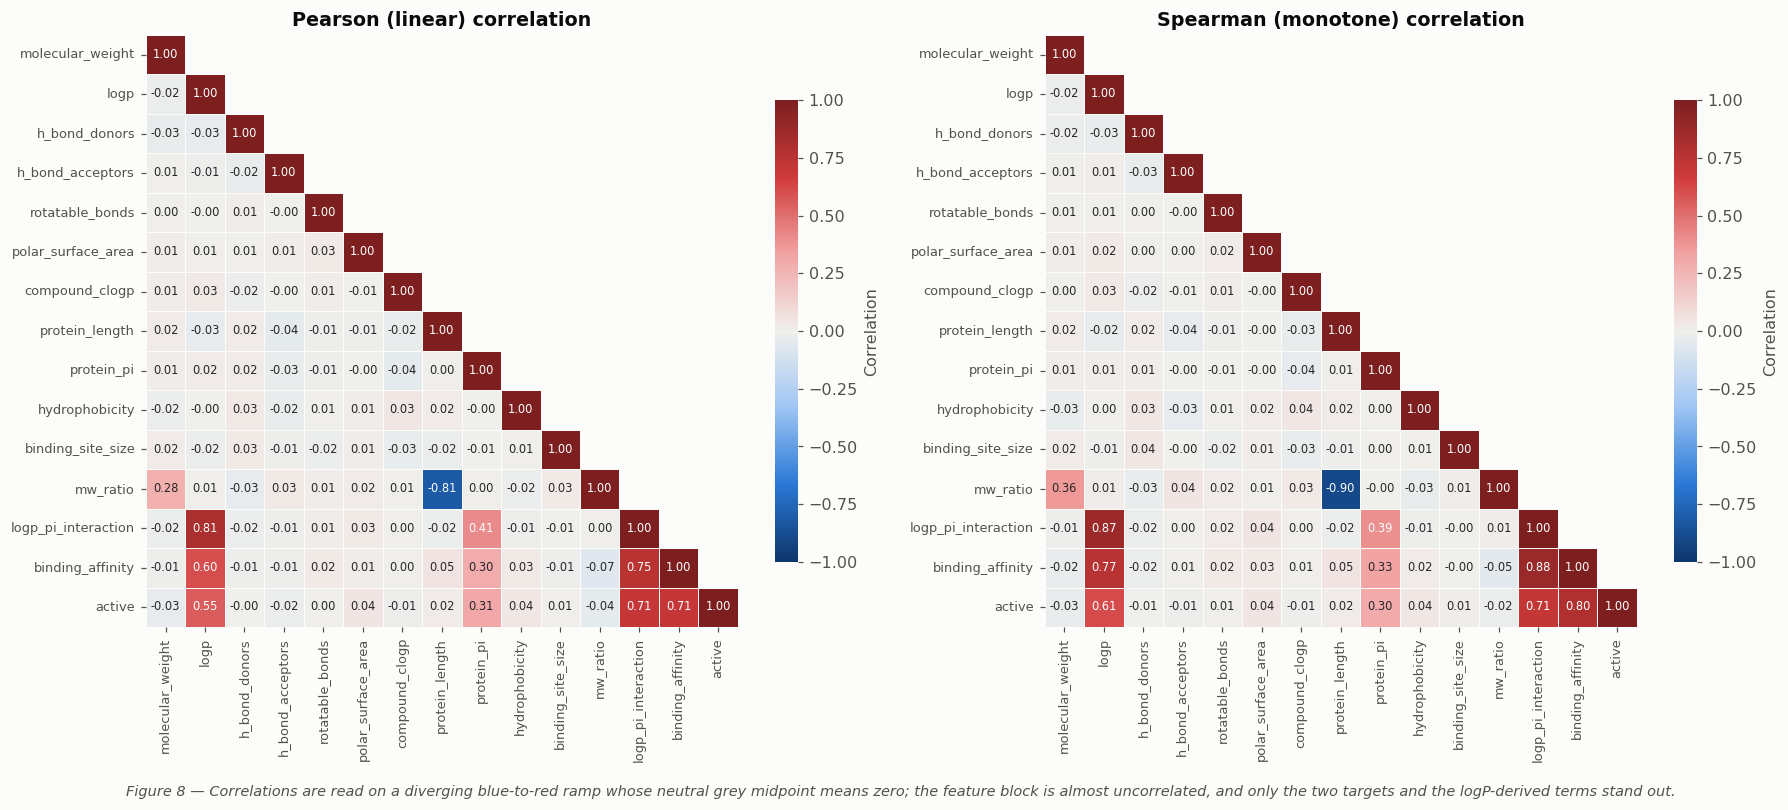

8

In [21]:
# Correlation structure (Pearson for linear, Spearman for monotone)
corr_cols = NUMERIC_COLS + [TARGET_REG, TARGET_CLF]
pearson = df[corr_cols].corr(method="pearson")
spearman = df[corr_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(16.5, 7))
for ax, matrix, name in zip(axes, [pearson, spearman], ["Pearson (linear)", "Spearman (monotone)"]):
    mask_up = np.triu(np.ones_like(matrix, dtype=bool), k=1)
    sns.heatmap(matrix, mask=mask_up, cmap=DIV_BLUE_RED, vmin=-1, vmax=1, center=0,
                annot=True, fmt=".2f", annot_kws={"size": 7.5}, linewidths=0.6,
                linecolor=SURFACE, square=True, cbar_kws={"shrink": 0.72, "label": "Correlation"},
                ax=ax)
    ax.set_title(f"{name} correlation")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelsize=8.5)
    ax.grid(visible=False)          # a grid line through every annotation would blur the numbers

finalize(fig, "Correlations are read on a diverging blue-to-red ramp whose neutral grey midpoint "
              "means zero; the feature block is almost uncorrelated, and only the two targets and "
              "the logP-derived terms stand out.",
         "08_correlation_matrices")

In [22]:
# What actually correlates with the targets?
assoc = pd.DataFrame({
    "pearson_vs_affinity": df[NUMERIC_COLS].corrwith(df[TARGET_REG]),
    "spearman_vs_affinity": df[NUMERIC_COLS].corrwith(df[TARGET_REG], method="spearman"),
    "point_biserial_vs_active": [stats.pointbiserialr(df[TARGET_CLF][df[c].notna()],
                                                      df[c].dropna())[0] for c in NUMERIC_COLS],
}).round(4)
assoc["abs_affinity"] = assoc["pearson_vs_affinity"].abs()
assoc = assoc.sort_values("abs_affinity", ascending=False).drop(columns="abs_affinity")
assoc

,pearson_vs_affinity,spearman_vs_affinity,point_biserial_vs_active
column,,,
logp_pi_interaction,0.7512,0.8792,0.7061
logp,0.6016,0.7650,0.5548
protein_pi,0.2956,0.3337,0.3078
mw_ratio,-0.0660,-0.0536,-0.0391
protein_length,0.0541,0.0486,0.0174
hydrophobicity,0.0284,0.0227,0.0361
rotatable_bonds,0.0241,0.0245,0.0032
h_bond_donors,-0.0141,-0.0210,-0.0018
polar_surface_area,0.0132,0.0261,0.0416


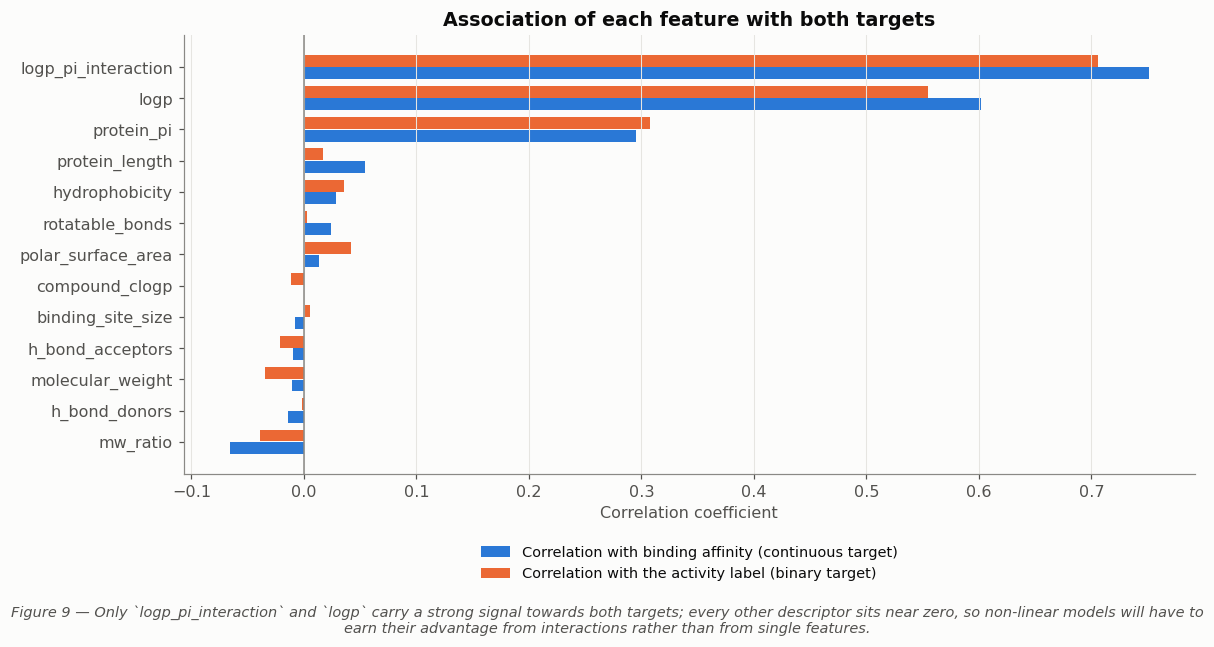

9

In [23]:
fig, ax = plt.subplots(figsize=(11, 5.6))
plot_df = assoc.sort_values("pearson_vs_affinity")
y = np.arange(len(plot_df))
ax.barh(y - 0.2, plot_df["pearson_vs_affinity"], height=0.38, color=CATEGORICAL[0],
        label="Correlation with binding affinity (continuous target)")
ax.barh(y + 0.2, plot_df["point_biserial_vs_active"], height=0.38, color=CATEGORICAL[1],
        label="Correlation with the activity label (binary target)")
ax.axvline(0, color=INK_MUTED, linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(plot_df.index)
ax.set_xlabel("Correlation coefficient")
ax.set_title("Association of each feature with both targets")
ax.grid(axis="y", visible=False)
legend_below(ax, ncol=1, y=-0.15)

finalize(fig, "Only `logp_pi_interaction` and `logp` carry a strong signal towards both targets; "
              "every other descriptor sits near zero, so non-linear models will have to earn their "
              "advantage from interactions rather than from single features.",
         "09_target_associations")

**Reading Figure 9.** Two features dominate: the shipped interaction term
`logp_pi_interaction` (r = 0.75 with affinity) and `logp` itself (r = 0.60). Because
`logp_pi_interaction` is close to `logp x protein_pi`, the underlying generative rule is clearly
*lipophilicity modulated by the isoelectric point of the target*. `protein_pi` alone reaches only
r = 0.30, which is the classic signature of an interaction effect: the product predicts far better
than either factor. All remaining descriptors are effectively noise with respect to the target,
which sets a realistic ceiling on achievable model performance.

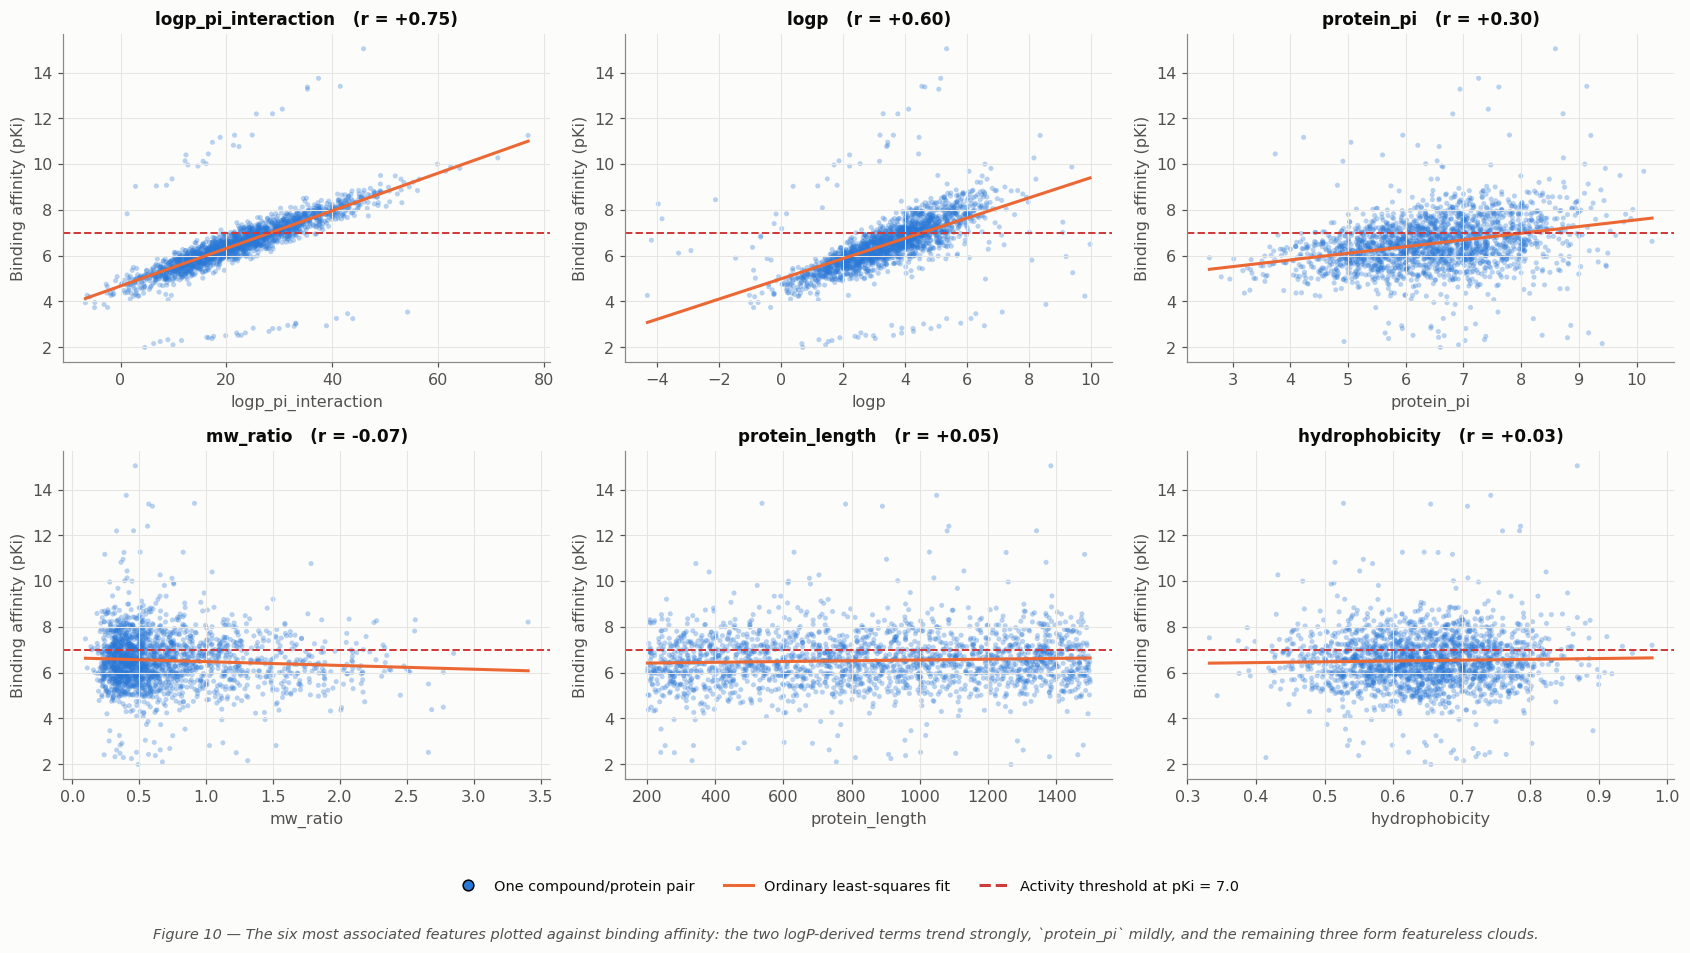

10

In [24]:
# The driving relationships, drawn
top_features = assoc["pearson_vs_affinity"].abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15.5, 8.6))
for ax, col in zip(axes.ravel(), top_features):
    sub = df[[col, TARGET_REG]].dropna()
    ax.scatter(sub[col], sub[TARGET_REG], s=11, alpha=0.32, color=CATEGORICAL[0],
               edgecolors="none", label="Compound")
    slope, intercept, r, p, se = stats.linregress(sub[col], sub[TARGET_REG])
    xs = np.linspace(sub[col].min(), sub[col].max(), 100)
    ax.plot(xs, intercept + slope * xs, color=CATEGORICAL[1], linewidth=2)
    ax.axhline(7.0, color=CRITICAL, linestyle="--", linewidth=1.3)
    ax.set_xlabel(col)
    ax.set_ylabel("Binding affinity (pKi)")
    # The correlation goes in the title, not in an in-plot legend box that would cover the data.
    ax.set_title(f"{col}   (r = {r:+.2f})", fontsize=11)

fig.legend(handles=[Line2D([], [], marker="o", color="none", markerfacecolor=CATEGORICAL[0], markersize=7),
                    Line2D([], [], color=CATEGORICAL[1], linewidth=2),
                    Line2D([], [], color=CRITICAL, linewidth=2, linestyle="--")],
           labels=["One compound/protein pair", "Ordinary least-squares fit",
                   "Activity threshold at pKi = 7.0"],
           loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.035))

finalize(fig, "The six most associated features plotted against binding affinity: the two "
              "logP-derived terms trend strongly, `protein_pi` mildly, and the remaining three "
              "form featureless clouds.",
         "10_top_feature_scatter", reserve=0.10)

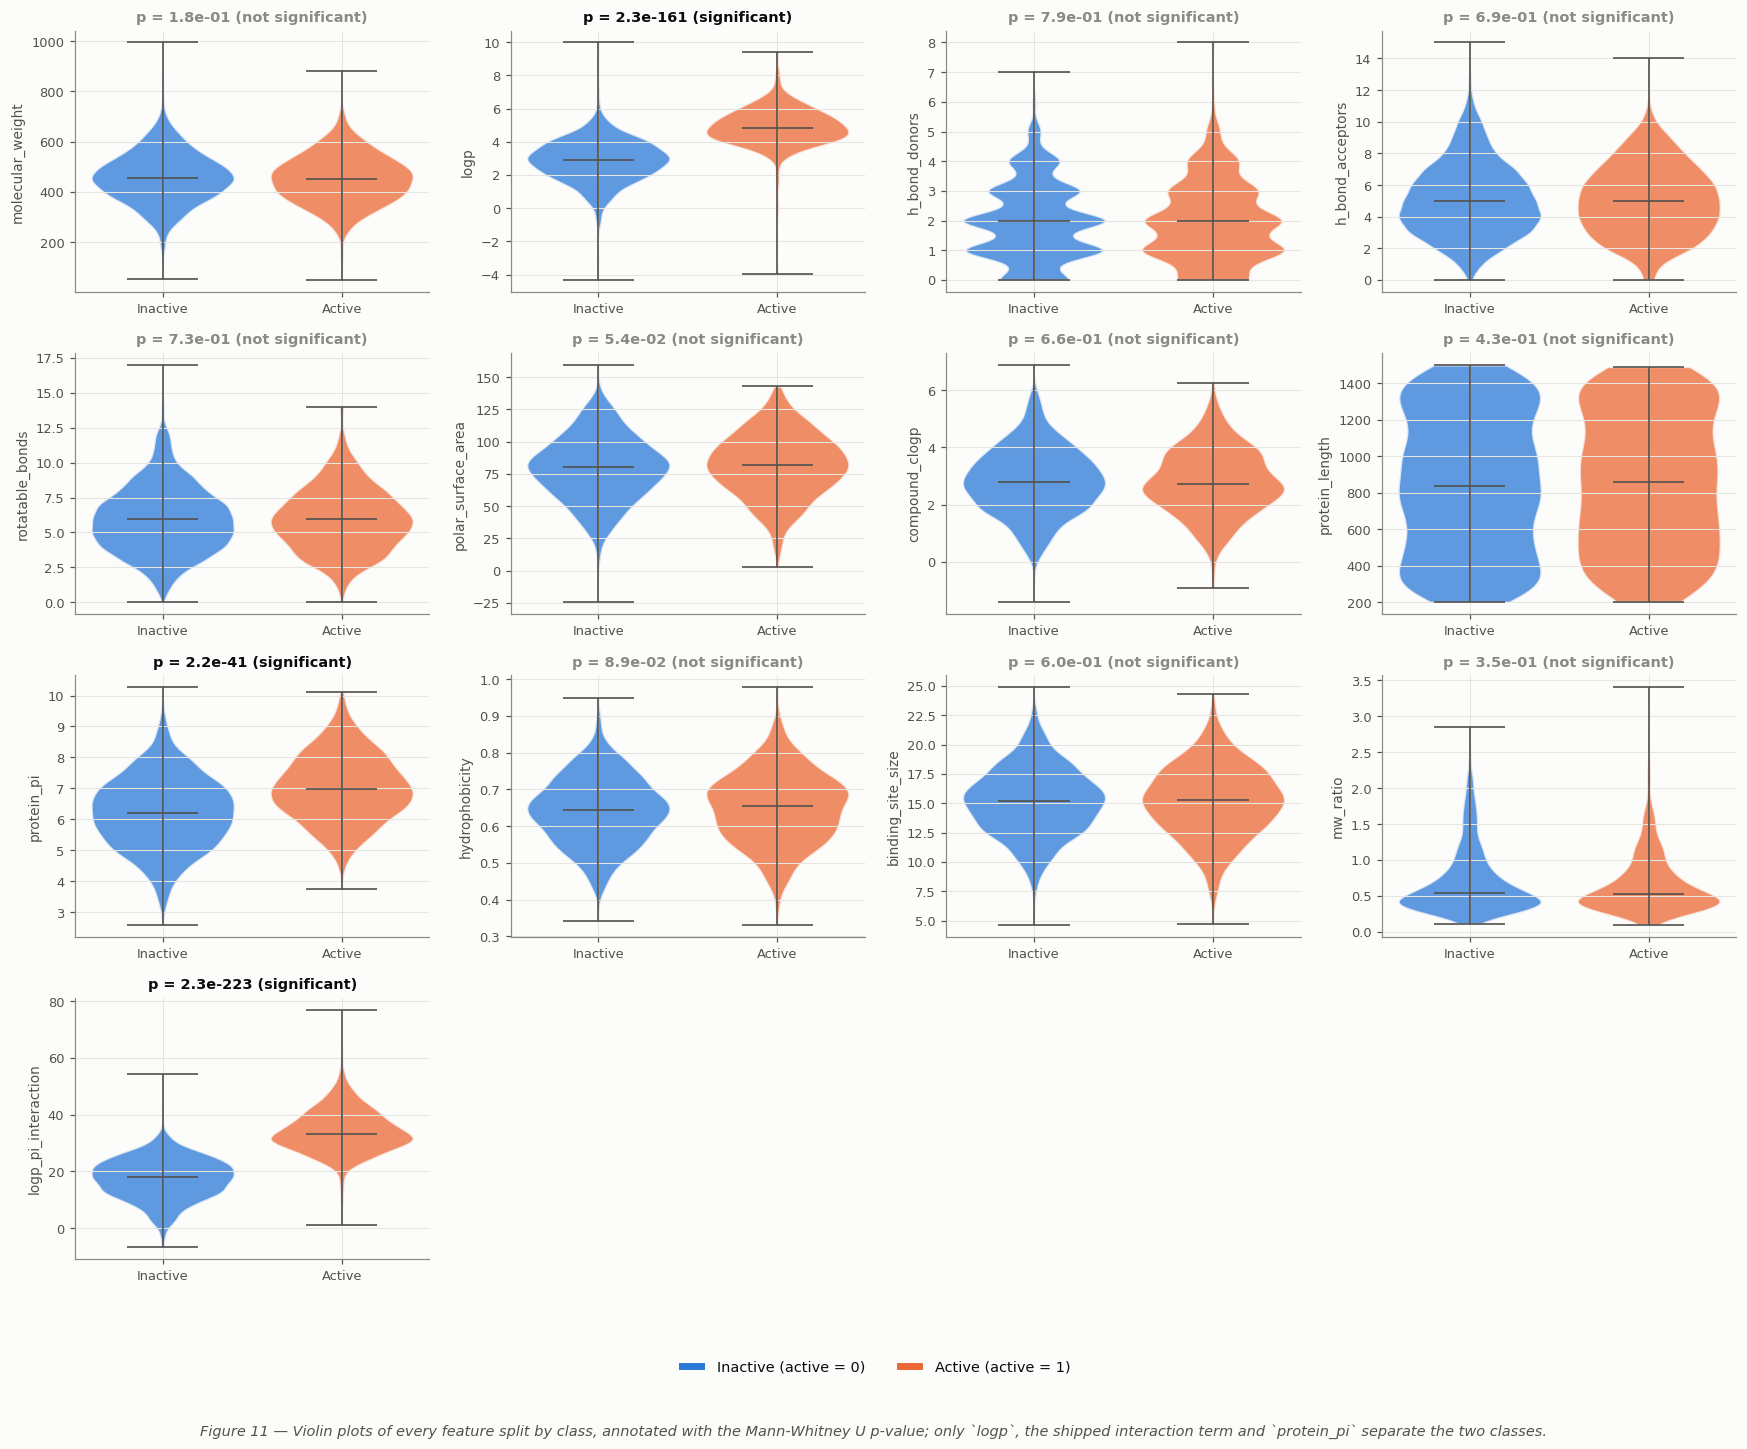

11

In [25]:
# Feature distributions split by activity class
VIOLIN_COLS = 4
VIOLIN_ROWS = int(np.ceil(len(NUMERIC_COLS) / VIOLIN_COLS))
fig, axes = plt.subplots(VIOLIN_ROWS, VIOLIN_COLS, figsize=(16, 3.3 * VIOLIN_ROWS))
for ax, col in zip(axes.ravel(), NUMERIC_COLS):
    data = [df.loc[df[TARGET_CLF] == k, col].dropna() for k in (0, 1)]
    parts = ax.violinplot(data, showmedians=True, widths=0.8)
    for body, k in zip(parts["bodies"], (0, 1)):
        body.set(facecolor=CLASS_COLORS[k], alpha=0.75, edgecolor=SURFACE, linewidth=1.5)
    for key in ("cmedians", "cbars", "cmins", "cmaxes"):
        parts[key].set(color=INK_SECONDARY, linewidth=1.1)
    u_stat, p_val = stats.mannwhitneyu(data[0], data[1])
    flag = "significant" if p_val < 0.05 else "not significant"
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Inactive", "Active"], fontsize=9)
    ax.set_ylabel(col, fontsize=9)
    ax.set_title(f"p = {p_val:.1e} ({flag})", fontsize=9.5,
                 color=INK_PRIMARY if p_val < 0.05 else INK_MUTED)
    ax.tick_params(labelsize=8.5)
for ax in axes.ravel()[len(NUMERIC_COLS):]:
    ax.remove()

handles, labels = class_legend_handles()
fig.legend(handles=handles, labels=labels, loc="lower center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 0.04))

finalize(fig, "Violin plots of every feature split by class, annotated with the Mann-Whitney U "
              "p-value; only `logp`, the shipped interaction term and `protein_pi` separate the "
              "two classes.",
         "11_violins_by_class", reserve=0.10)

---
## 7. The categorical variables

Two columns are non-numeric: `compound_id` and `protein_id`. They must be treated very
differently, and getting that wrong is the most common modelling mistake on this dataset.

In [26]:
# Cardinality profile
cat_profile = pd.DataFrame([
    {"column": c,
     "levels": df[c].nunique(),
     "levels_per_row": round(df[c].nunique() / len(df), 3),
     "most_frequent": df[c].mode()[0],
     "max_frequency": int(df[c].value_counts().max()),
     "min_frequency": int(df[c].value_counts().min()),
     "mean_frequency": round(df[c].value_counts().mean(), 2)}
    for c in ID_COLS + CATEGORICAL_COLS])
cat_profile

,column,levels,levels_per_row,most_frequent,max_frequency,min_frequency,mean_frequency
0,compound_id,2000,1.0,CID_00000,1,1,1.0
1,protein_id,400,0.2,PID_131,11,1,5.0


**How each one must be handled.**

| Column | Levels | Decision | Reason |
|---|---|---|---|
| `compound_id` | 2,000 (one per row) | **Drop** | A perfect key. Encoding it lets a tree memorise the training rows and generalises to nothing. |
| `protein_id` | 400 (≈5 rows each) | **Label-encode** | A genuine categorical target identifier that may carry a protein-specific effect. |

Label encoding turns each protein identifier into an integer. That integer is *ordinal by
accident*, which is harmless for tree-based models (they split on thresholds and can isolate any
subset with enough splits) but is a modelling assumption for linear models, which is why the
companion notebook also derives explicit protein-level numeric features.

In [27]:
# How many compounds were screened against each protein?
per_protein = (df.groupby("protein_id")
                 .agg(n_compounds=("compound_id", "size"),
                      mean_affinity=(TARGET_REG, "mean"),
                      active_rate=(TARGET_CLF, "mean"))
                 .sort_values("n_compounds", ascending=False))

print(f"Distinct proteins: {per_protein.shape[0]}")
print(f"Compounds per protein - min {per_protein['n_compounds'].min()}, "
      f"median {per_protein['n_compounds'].median():.0f}, max {per_protein['n_compounds'].max()}")
print(f"Proteins seen only once: {(per_protein['n_compounds'] == 1).sum()} "
      f"({(per_protein['n_compounds'] == 1).mean() * 100:.1f}%)")
per_protein.head(10).round(3)

Distinct proteins: 400
Compounds per protein - min 1, median 5, max 11
Proteins seen only once: 16 (4.0%)


,n_compounds,mean_affinity,active_rate
protein_id,,,
PID_131,11,5.839,0.000
PID_170,11,6.678,0.455
PID_286,10,6.764,0.300
PID_226,10,6.469,0.300
PID_125,10,6.276,0.400
PID_371,10,6.549,0.200
PID_237,10,6.496,0.400
PID_375,10,6.318,0.200
PID_464,10,6.480,0.300


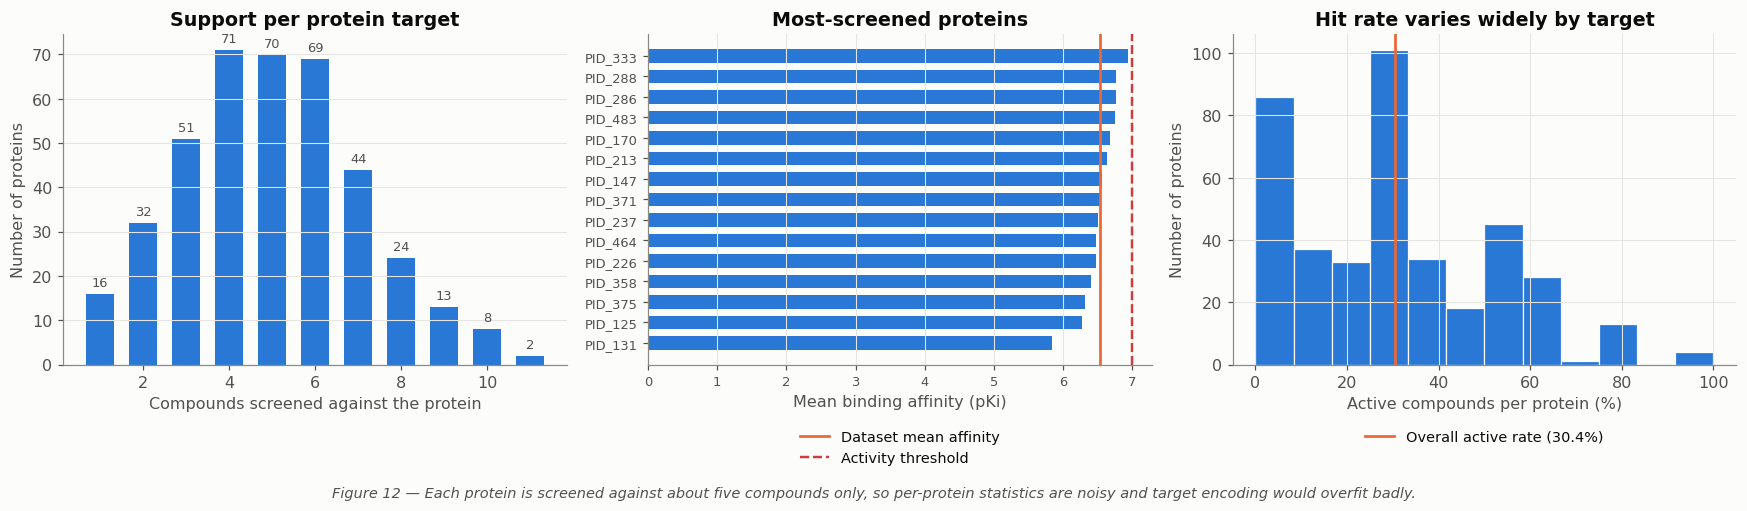

12

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

ax = axes[0]
freq = per_protein["n_compounds"].value_counts().sort_index()
bars = ax.bar(freq.index, freq.values, color=CATEGORICAL[0], width=0.65)
ax.bar_label(bars, padding=3, fontsize=8.5, color=INK_SECONDARY)
ax.set_xlabel("Compounds screened against the protein")
ax.set_ylabel("Number of proteins")
ax.set_title("Support per protein target")
ax.grid(axis="x", visible=False)

ax = axes[1]
top = per_protein.head(15).sort_values("mean_affinity")
ax.barh(top.index, top["mean_affinity"], color=CATEGORICAL[0], height=0.65)
ax.axvline(df[TARGET_REG].mean(), color=CATEGORICAL[1], linewidth=1.8,
           label="Dataset mean affinity")
ax.axvline(7.0, color=CRITICAL, linestyle="--", linewidth=1.6, label="Activity threshold")
ax.set_xlabel("Mean binding affinity (pKi)")
ax.set_title("Most-screened proteins")
ax.tick_params(labelsize=8.5)
ax.grid(axis="y", visible=False)
legend_below(ax, ncol=1, y=-0.18)

ax = axes[2]
ax.hist(per_protein["active_rate"] * 100, bins=12, color=CATEGORICAL[0],
        edgecolor=SURFACE, linewidth=0.8)
ax.axvline(df[TARGET_CLF].mean() * 100, color=CATEGORICAL[1], linewidth=1.8,
           label=f"Overall active rate ({df[TARGET_CLF].mean() * 100:.1f}%)")
ax.set_xlabel("Active compounds per protein (%)")
ax.set_ylabel("Number of proteins")
ax.set_title("Hit rate varies widely by target")
legend_below(ax, ncol=1, y=-0.18)

finalize(fig, "Each protein is screened against about five compounds only, so per-protein "
              "statistics are noisy and target encoding would overfit badly.",
         "12_protein_support")

**Reading Figure 12.** With a median of five compounds per protein, any statistic computed per
protein rests on a handful of observations. That is precisely why **target/mean encoding is
rejected** for this dataset in favour of the label encoding requested for the modelling notebook:
a mean affinity computed on five rows is mostly noise and leaks the target into the feature.

In [29]:
# Does the protein identity carry a real effect? (one-way ANOVA + Kruskal-Wallis)
groups = [g[TARGET_REG].values for _, g in df.groupby("protein_id") if len(g) >= 4]
f_stat, p_anova = stats.f_oneway(*groups)
h_stat, p_kw = stats.kruskal(*groups)

# Eta squared must be computed inside the SAME subset the ANOVA used, otherwise the numerator and
# the denominator describe different populations.
subset = np.concatenate(groups)
subset_mean = subset.mean()
ss_between = sum(len(g) * (g.mean() - subset_mean) ** 2 for g in groups)
ss_total = ((subset - subset_mean) ** 2).sum()
eta_squared = ss_between / ss_total

# Eta squared is biased upwards by the sheer number of groups: even with no real effect at all,
# k - 1 free parameters fitted on n points already "explain" (k - 1) / (n - 1) of the variance.
n_groups, n_rows = len(groups), len(subset)
eta_squared_under_null = (n_groups - 1) / (n_rows - 1)

print(f"Proteins with at least 4 compounds : {n_groups} ({n_rows} compounds)")
print(f"One-way ANOVA   : F = {f_stat:.3f}, p = {p_anova:.4f}")
print(f"Kruskal-Wallis  : H = {h_stat:.3f}, p = {p_kw:.4f}")
print(f"Eta squared (raw)                    = {eta_squared:.4f}")
print(f"Eta squared expected under the null  = {eta_squared_under_null:.4f}")
print(f"Excess over the null expectation     = {eta_squared - eta_squared_under_null:+.4f}")
print("\nConclusion:",
      "protein identity explains a meaningful share of the affinity variance."
      if p_anova < 0.05 else
      "protein identity alone does NOT explain the affinity variance. The raw eta squared looks "
      "sizeable only because 300 group means are fitted on 1,767 rows; it is within a whisker of "
      "what pure noise would produce. The protein acts only through its measured properties "
      "(pI, length, hydrophobicity, binding-site size).")

Proteins with at least 4 compounds : 301 (1767 compounds)
One-way ANOVA   : F = 1.010, p = 0.4491
Kruskal-Wallis  : H = 315.402, p = 0.2593
Eta squared (raw)                    = 0.1712
Eta squared expected under the null  = 0.1699
Excess over the null expectation     = +0.0014

Conclusion: protein identity alone does NOT explain the affinity variance. The raw eta squared looks sizeable only because 300 group means are fitted on 1,767 rows; it is within a whisker of what pure noise would produce. The protein acts only through its measured properties (pI, length, hydrophobicity, binding-site size).


**A worked example of a statistic that lies.** Read on its own, "protein identity explains 17% of
the affinity variance" sounds like a finding. It is an artefact. Fitting 300 free group means to
1,767 observations mechanically absorbs about 17% of the variance **even when the groups are pure
noise** — which is exactly the number printed above as the null expectation. The excess over that
baseline is essentially zero, and both the F test (p ≈ 0.45) and the Kruskal-Wallis test (p ≈ 0.26)
agree that there is nothing there.

The practical consequence for the modelling notebook is concrete: **`protein_id` should not be
target-encoded.** A per-protein mean affinity would look informative for the same
degrees-of-freedom reason and would carry the target straight into the feature matrix. Label
encoding, which is what the modelling notebook uses, injects no target information at all.

---
## 8. Domain view: drug-likeness rules

Virtual screening is not a purely statistical exercise. Two classic medicinal-chemistry filters
are computed here and related to measured activity.

* **Lipinski's Rule of Five** (oral bioavailability): molecular weight ≤ 500 g/mol, logP ≤ 5,
  hydrogen-bond donors ≤ 5, hydrogen-bond acceptors ≤ 10. A compound is usually accepted if it
  violates at most one of the four.
* **Veber rules** (oral bioavailability, complementary): rotatable bonds ≤ 10 and polar surface
  area ≤ 140 Å².

In [30]:
# Compute the rule violations
rules = pd.DataFrame(index=df.index)
rules["mw_over_500"] = (df["molecular_weight"] > 500).astype(int)
rules["logp_over_5"] = (df["logp"] > 5).astype(int)
rules["hbd_over_5"] = (df["h_bond_donors"] > 5).astype(int)
rules["hba_over_10"] = (df["h_bond_acceptors"] > 10).astype(int)
rules["lipinski_violations"] = rules[["mw_over_500", "logp_over_5", "hbd_over_5", "hba_over_10"]].sum(axis=1)
rules["lipinski_pass"] = (rules["lipinski_violations"] <= 1).astype(int)

rules["rotb_over_10"] = (df["rotatable_bonds"] > 10).astype(int)
rules["tpsa_over_140"] = (df["polar_surface_area"] > 140).astype(int)
rules["veber_pass"] = ((rules["rotb_over_10"] + rules["tpsa_over_140"]) == 0).astype(int)
rules["drug_like"] = (rules["lipinski_pass"] & rules["veber_pass"]).astype(int)
rules[TARGET_CLF] = df[TARGET_CLF]
rules[TARGET_REG] = df[TARGET_REG]

summary = pd.DataFrame({
    "rule": ["Molecular weight > 500", "logP > 5", "H-bond donors > 5", "H-bond acceptors > 10",
             "Rotatable bonds > 10", "Polar surface area > 140",
             "Passes Rule of Five (<= 1 violation)", "Passes Veber rules", "Drug-like (both)"],
    "compounds": [rules[c].sum() for c in ["mw_over_500", "logp_over_5", "hbd_over_5",
                                           "hba_over_10", "rotb_over_10", "tpsa_over_140",
                                           "lipinski_pass", "veber_pass", "drug_like"]],
})
summary["share_pct"] = (summary["compounds"] / len(df) * 100).round(1)
summary

,rule,compounds,share_pct
0,Molecular weight > 500,654,32.7
1,logP > 5,320,16.0
2,H-bond donors > 5,18,0.9
3,H-bond acceptors > 10,32,1.6
4,Rotatable bonds > 10,83,4.2
5,Polar surface area > 140,9,0.4
6,Passes Rule of Five (<= 1 violation),1874,93.7
7,Passes Veber rules,1910,95.5
8,Drug-like (both),1787,89.4


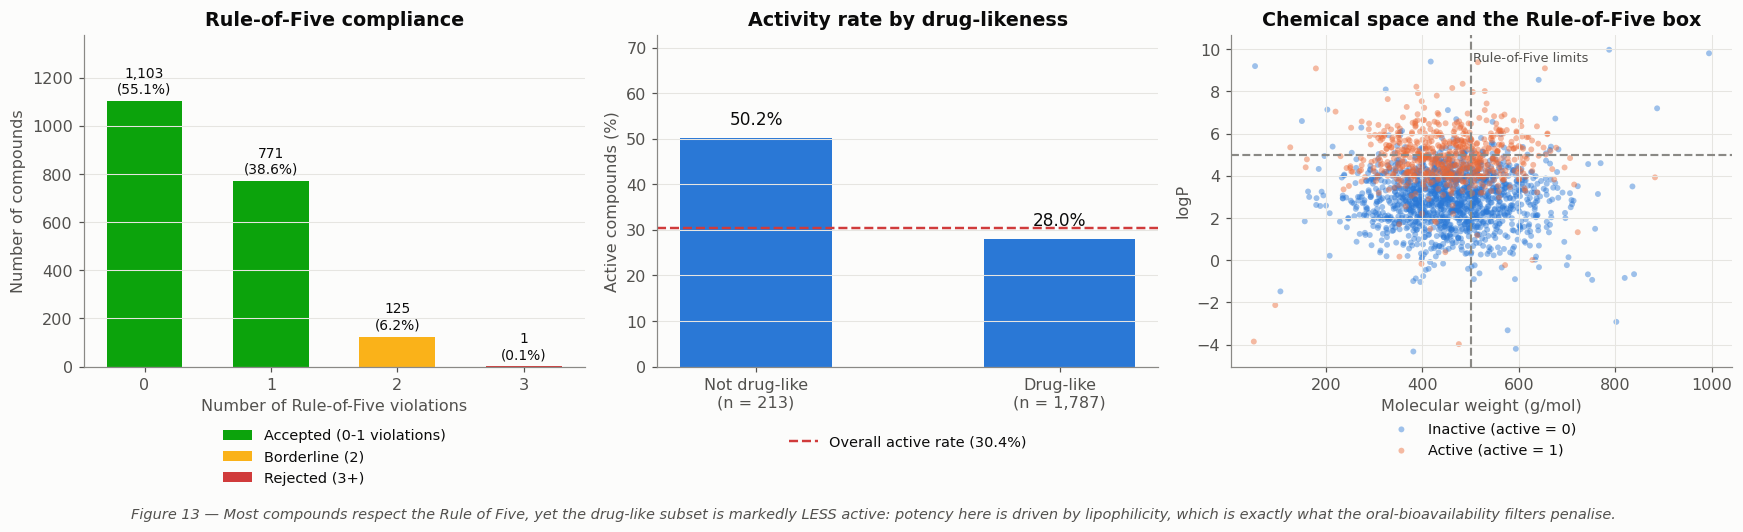

13

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

ax = axes[0]
viol = rules["lipinski_violations"].value_counts().sort_index()
colors = [GOOD if k <= 1 else (WARNING if k == 2 else CRITICAL) for k in viol.index]
bars = ax.bar(viol.index.astype(str), viol.values, color=colors, width=0.6)
ax.bar_label(bars, labels=[f"{v:,}\n({v / len(df) * 100:.1f}%)" for v in viol.values],
             padding=3, fontsize=9, color=INK_PRIMARY)
ax.set_xlabel("Number of Rule-of-Five violations")
ax.set_ylabel("Number of compounds")
ax.set_ylim(0, viol.max() * 1.25)
ax.set_title("Rule-of-Five compliance")
ax.grid(axis="x", visible=False)
legend_below(ax, [Patch(facecolor=GOOD), Patch(facecolor=WARNING), Patch(facecolor=CRITICAL)],
             ["Accepted (0-1 violations)", "Borderline (2)", "Rejected (3+)"], ncol=1, y=-0.17)

ax = axes[1]
rate = rules.groupby("drug_like")[TARGET_CLF].agg(["mean", "size"])
# One measure (activity rate) across two groups, so a single hue is the correct encoding. The
# blue/orange class palette stays reserved for active/inactive and is never reused for another
# meaning inside the same figure.
bars = ax.bar([f"Not drug-like\n(n = {rate['size'].iloc[0]:,})",
               f"Drug-like\n(n = {rate['size'].iloc[1]:,})"],
              rate["mean"] * 100, color=CATEGORICAL[0], width=0.5)
ax.bar_label(bars, fmt="%.1f%%", padding=6, fontsize=11, color=INK_PRIMARY)
ax.axhline(df[TARGET_CLF].mean() * 100, color=CRITICAL, linestyle="--", linewidth=1.6,
           label=f"Overall active rate ({df[TARGET_CLF].mean() * 100:.1f}%)")
ax.set_ylabel("Active compounds (%)")
ax.set_ylim(0, max(rate["mean"] * 100) * 1.45)
ax.set_title("Activity rate by drug-likeness")
ax.grid(axis="x", visible=False)
legend_below(ax, ncol=1, y=-0.19)

ax = axes[2]
for k in (0, 1):
    sub = df[df[TARGET_CLF] == k]
    ax.scatter(sub["molecular_weight"], sub["logp"], s=15, alpha=0.45,
               color=CLASS_COLORS[k], edgecolors="none", label=CLASS_LABELS[k])
ax.axvline(500, color=INK_MUTED, linestyle="--", linewidth=1.4)
ax.axhline(5, color=INK_MUTED, linestyle="--", linewidth=1.4)
ax.text(505, 9.4, "Rule-of-Five limits", fontsize=8.5, color=INK_SECONDARY)
ax.set_xlabel("Molecular weight (g/mol)")
ax.set_ylabel("logP")
ax.set_title("Chemical space and the Rule-of-Five box")
legend_below(ax, ncol=1, y=-0.15)

finalize(fig, "Most compounds respect the Rule of Five, yet the drug-like subset is markedly LESS "
              "active: potency here is driven by lipophilicity, which is exactly what the "
              "oral-bioavailability filters penalise.",
         "13_drug_likeness")

**Reading Figure 13 — the potency / drug-likeness trade-off.** 89% of the library passes both
filters, but the active rate inside the drug-like subset is around 28% against roughly 50% among
the compounds that fail them. The direction is counter-intuitive only at first sight: binding
affinity in this dataset is driven by `logp`, and the Rule of Five explicitly caps `logp` at 5 and
molecular weight at 500. The filters therefore remove precisely the region of chemical space where
the strongest binders live — the classic potency-versus-developability trade-off seen in real
medicinal-chemistry programmes. The flag is a genuinely informative feature, and its sign is the
opposite of what a naive prior would assume.

In [32]:
# Is the drug-likeness flag statistically associated with activity?
tbl = pd.crosstab(rules["drug_like"], rules[TARGET_CLF])
chi2, p_val, dof, expected = stats.chi2_contingency(tbl)
odds_ratio = (tbl.iloc[1, 1] * tbl.iloc[0, 0]) / (tbl.iloc[1, 0] * tbl.iloc[0, 1])

print(tbl.rename(index={0: "Not drug-like", 1: "Drug-like"},
                 columns={0: "Inactive", 1: "Active"}))
print(f"\nChi-square = {chi2:.3f}, p = {p_val:.4f}, odds ratio = {odds_ratio:.3f}")
print("The drug-likeness flag is",
      "a useful engineered feature." if p_val < 0.05 else
      "NOT significantly associated with activity, but it is kept as a cheap descriptor "
      "because tree models can still exploit it inside interactions.")

active         Inactive  Active
drug_like                      
Not drug-like       106     107
Drug-like          1286     501

Chi-square = 43.283, p = 0.0000, odds ratio = 0.386
The drug-likeness flag is a useful engineered feature.


---
## 9. Multivariate structure

Components needed for 90% of the variance: 10 out of 13
Variance explained by the first five components: PC1 14.7%, PC2 14.3%, PC3 8.4%, PC4 8.1%, PC5 7.9%


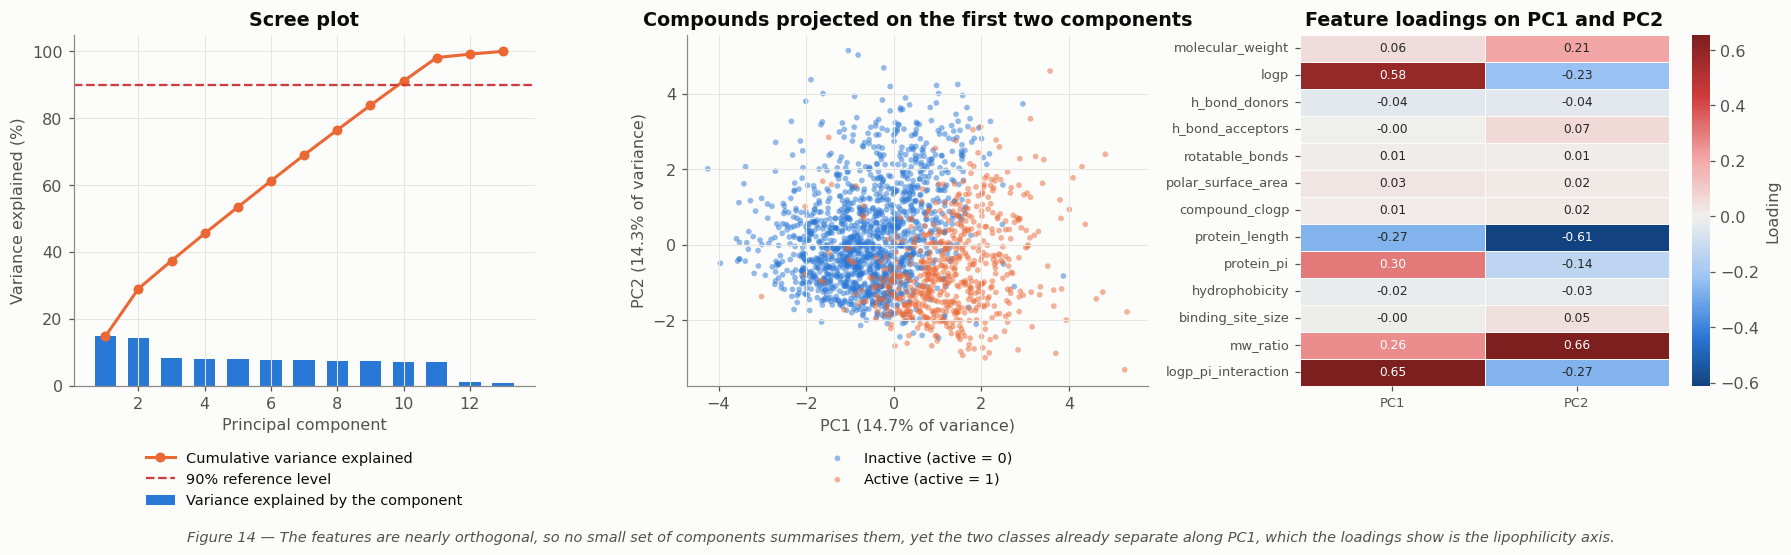

14

In [33]:
# Principal component analysis
X_num = SimpleImputer(strategy="median").fit_transform(df[NUMERIC_COLS])
X_std = StandardScaler().fit_transform(X_num)

pca = PCA(random_state=RANDOM_STATE).fit(X_std)
scores = pca.transform(X_std)
explained = pca.explained_variance_ratio_ * 100
cumulative = explained.cumsum()
n_for_90 = int(np.searchsorted(cumulative, 90) + 1)

print(f"Components needed for 90% of the variance: {n_for_90} out of {len(NUMERIC_COLS)}")
print("Variance explained by the first five components: " +
      ", ".join(f"PC{i + 1} {explained[i]:.1f}%" for i in range(5)))

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5))

ax = axes[0]
bars = ax.bar(np.arange(1, len(explained) + 1), explained, color=CATEGORICAL[0], width=0.65,
              label="Variance explained by the component")
ax.plot(np.arange(1, len(cumulative) + 1), cumulative, color=CATEGORICAL[1], marker="o",
        label="Cumulative variance explained")
ax.axhline(90, color=CRITICAL, linestyle="--", linewidth=1.5, label="90% reference level")
ax.set_xlabel("Principal component")
ax.set_ylabel("Variance explained (%)")
ax.set_title("Scree plot")
legend_below(ax, ncol=1, y=-0.17)

ax = axes[1]
for k in (0, 1):
    sel = df[TARGET_CLF].values == k
    ax.scatter(scores[sel, 0], scores[sel, 1], s=14, alpha=0.5, color=CLASS_COLORS[k],
               edgecolors="none", label=CLASS_LABELS[k])
ax.set_xlabel(f"PC1 ({explained[0]:.1f}% of variance)")
ax.set_ylabel(f"PC2 ({explained[1]:.1f}% of variance)")
ax.set_title("Compounds projected on the first two components")
legend_below(ax, ncol=1, y=-0.17)

ax = axes[2]
loadings = pd.DataFrame(pca.components_[:2].T, index=NUMERIC_COLS, columns=["PC1", "PC2"])
sns.heatmap(loadings, cmap=DIV_BLUE_RED, center=0, annot=True, fmt=".2f",
            annot_kws={"size": 8}, linewidths=0.6, linecolor=SURFACE,
            cbar_kws={"label": "Loading"}, ax=ax)
ax.set_title("Feature loadings on PC1 and PC2")
ax.tick_params(labelsize=8.5)
ax.grid(visible=False)          # a grid line through every annotation would blur the numbers

finalize(fig, "The features are nearly orthogonal, so no small set of components summarises them, "
              "yet the two classes already separate along PC1, which the loadings show is the "
              "lipophilicity axis.",
         "14_pca")

**Reading Figure 14, and a prediction that the modelling notebook will test.** The scree plot is
almost flat — the first component captures under 15% of the variance and **10 of the 13
components** are needed to reach 90%. That is the signature of weakly correlated descriptors:
dimensionality reduction would destroy information rather than compress it, so PCA is **not** used
as a preprocessing step in the modelling notebook.

The middle and right panels together say something more useful. PC1 is loaded almost entirely on
`logp_pi_interaction` (0.65), `logp` (0.58) and `protein_pi` (0.30) — it *is* the lipophilicity
axis — and the two classes visibly separate along it, even though PC1 explains only 14.7% of the
total variance. The classes overlap but the boundary runs roughly perpendicular to a single
direction, which means **a linear decision boundary should already work well**. That is a concrete,
falsifiable prediction, and section 7 of `02_machine_learning_models.ipynb` puts it to the test
against nine non-linear competitors.

  File "C:\Users\rafae.RAFAEL_NOTEBOOK\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\rafae.RAFAEL_NOTEBOOK\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\rafae.RAFAEL_NOTEBOOK\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\rafae.RAFAEL_NOTEBOOK\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


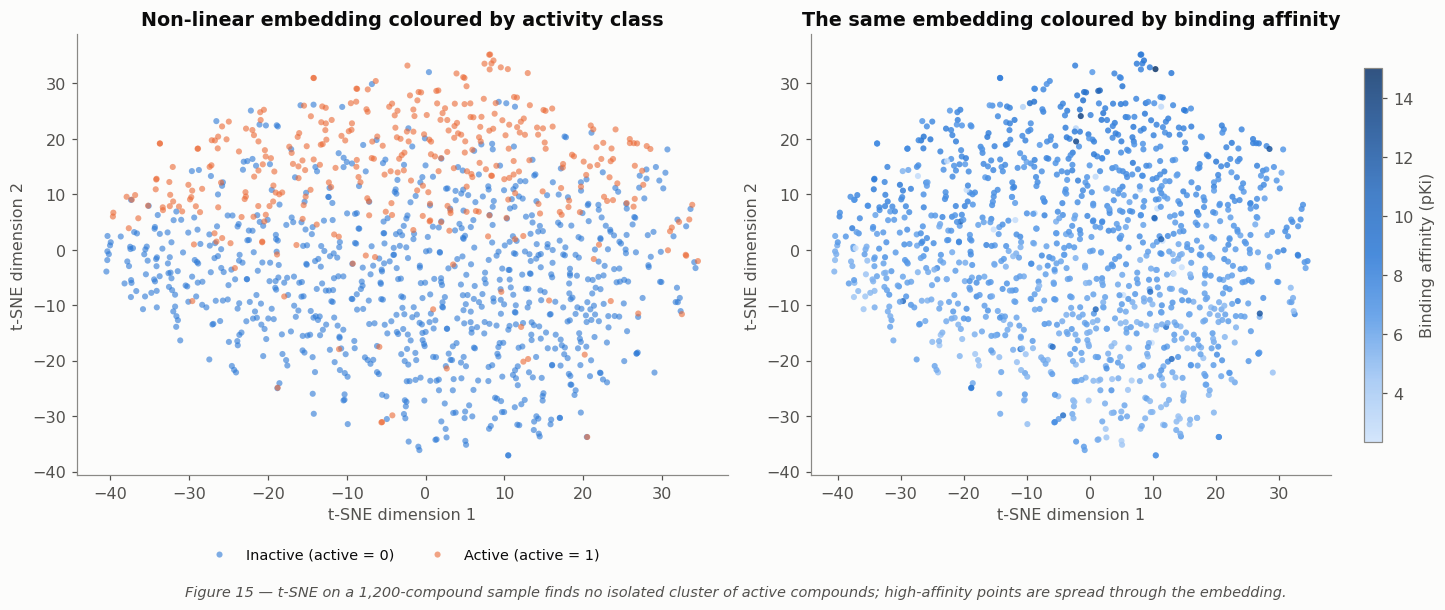

15

In [34]:
# t-SNE: is there any local structure the linear projection misses?
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(df), size=1200, replace=False)
tsne = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto",
            random_state=RANDOM_STATE, n_iter=750)
emb = tsne.fit_transform(X_std[sample_idx])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))

ax = axes[0]
for k in (0, 1):
    sel = df[TARGET_CLF].values[sample_idx] == k
    ax.scatter(emb[sel, 0], emb[sel, 1], s=16, alpha=0.6, color=CLASS_COLORS[k],
               edgecolors="none", label=CLASS_LABELS[k])
ax.set_xlabel("t-SNE dimension 1")
ax.set_ylabel("t-SNE dimension 2")
ax.set_title("Non-linear embedding coloured by activity class")
ax.grid(visible=False)
legend_below(ax, ncol=2, y=-0.15)

ax = axes[1]
sc = ax.scatter(emb[:, 0], emb[:, 1], c=df[TARGET_REG].values[sample_idx], s=16,
                cmap=SEQ_BLUE, alpha=0.85, edgecolors="none")
cbar = fig.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label("Binding affinity (pKi)", color=INK_SECONDARY)
ax.set_xlabel("t-SNE dimension 1")
ax.set_ylabel("t-SNE dimension 2")
ax.set_title("The same embedding coloured by binding affinity")
ax.grid(visible=False)

finalize(fig, "t-SNE on a 1,200-compound sample finds no isolated cluster of active compounds; "
              "high-affinity points are spread through the embedding.",
         "15_tsne")

**Reading Figure 15.** Neither the class labels nor the affinity gradient form compact islands.
Activity in this dataset is a **smooth function of a couple of continuous descriptors**, not a
clustering phenomenon, which means neighbourhood methods such as k-nearest neighbours are
unlikely to lead the model comparison.

---
## 10. Statistical testing and feature ranking

Correlation alone is a weak screen: it only sees linear (or monotone) trends. This section adds
significance tests with effect sizes and a non-parametric mutual-information ranking that also
captures non-monotone dependence.

In [35]:
# Significance and effect size of every feature, per class
def cohens_d(a, b):
    """Standardised mean difference between two independent samples."""
    na, nb = len(a), len(b)
    pooled = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (b.mean() - a.mean()) / pooled if pooled > 0 else 0.0


tests = []
for col in NUMERIC_COLS:
    inactive = df.loc[df[TARGET_CLF] == 0, col].dropna()
    active = df.loc[df[TARGET_CLF] == 1, col].dropna()
    t_stat, p_t = stats.ttest_ind(inactive, active, equal_var=False)
    u_stat, p_u = stats.mannwhitneyu(inactive, active)
    d = cohens_d(inactive, active)
    tests.append({
        "feature": col,
        "mean_inactive": inactive.mean(),
        "mean_active": active.mean(),
        "difference": active.mean() - inactive.mean(),
        "welch_p": p_t,
        "mannwhitney_p": p_u,
        "cohens_d": d,
        "effect_size": ("negligible" if abs(d) < 0.2 else "small" if abs(d) < 0.5
                        else "medium" if abs(d) < 0.8 else "large"),
    })

tests_df = pd.DataFrame(tests)
# Benjamini-Hochberg correction, because 13 features are tested at once.
order = tests_df["mannwhitney_p"].rank(method="first")
tests_df["bh_significant"] = tests_df["mannwhitney_p"] <= (0.05 * order / len(tests_df))
tests_df = tests_df.sort_values("cohens_d", key=np.abs, ascending=False).reset_index(drop=True)
tests_df.round(4)

,feature,mean_inactive,mean_active,difference,welch_p,mannwhitney_p,cohens_d,effect_size,bh_significant
0,logp_pi_interaction,17.5043,34.2610,16.7567,0.0000,0.0000,2.1669,large,True
1,logp,2.8787,4.8542,1.9755,0.0000,0.0000,1.4486,large,True
2,protein_pi,6.2142,7.0238,0.8095,0.0000,0.0000,0.7028,medium,True
3,polar_surface_area,79.3313,81.6211,2.2899,0.0660,0.0535,0.0904,negligible,False
4,mw_ratio,0.7213,0.6808,-0.0404,0.0681,0.3509,-0.0851,negligible,False
5,hydrophobicity,0.6431,0.6505,0.0075,0.1205,0.0885,0.0784,negligible,False
6,molecular_weight,459.1625,451.2996,-7.8628,0.1171,0.1835,-0.0750,negligible,False
7,h_bond_acceptors,5.1480,5.0395,-0.1085,0.3304,0.6866,-0.0466,negligible,False
8,protein_length,844.5546,858.9342,14.3796,0.4344,0.4251,0.0378,negligible,False
9,compound_clogp,2.8222,2.7932,-0.0290,0.6142,0.6642,-0.0244,negligible,False


In [36]:
# Mutual information towards both targets
X_mi = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(df[NUMERIC_COLS]),
                    columns=NUMERIC_COLS)

mi_clf = mutual_info_classif(X_mi, df[TARGET_CLF], random_state=RANDOM_STATE)
mi_reg = mutual_info_regression(X_mi, df[TARGET_REG], random_state=RANDOM_STATE)

mi = pd.DataFrame({"feature": NUMERIC_COLS,
                   "mutual_info_active": mi_clf,
                   "mutual_info_affinity": mi_reg}).sort_values("mutual_info_affinity",
                                                                ascending=False)
mi.round(4).reset_index(drop=True)

,feature,mutual_info_active,mutual_info_affinity
0,logp_pi_interaction,0.3517,1.0746
1,logp,0.2257,0.6320
2,protein_pi,0.0476,0.0759
3,polar_surface_area,0.0076,0.0196
4,h_bond_acceptors,0.0074,0.0159
5,molecular_weight,0.0000,0.0131
6,hydrophobicity,0.0000,0.0019
7,h_bond_donors,0.0000,0.0000
8,rotatable_bonds,0.0000,0.0000
9,compound_clogp,0.0000,0.0000


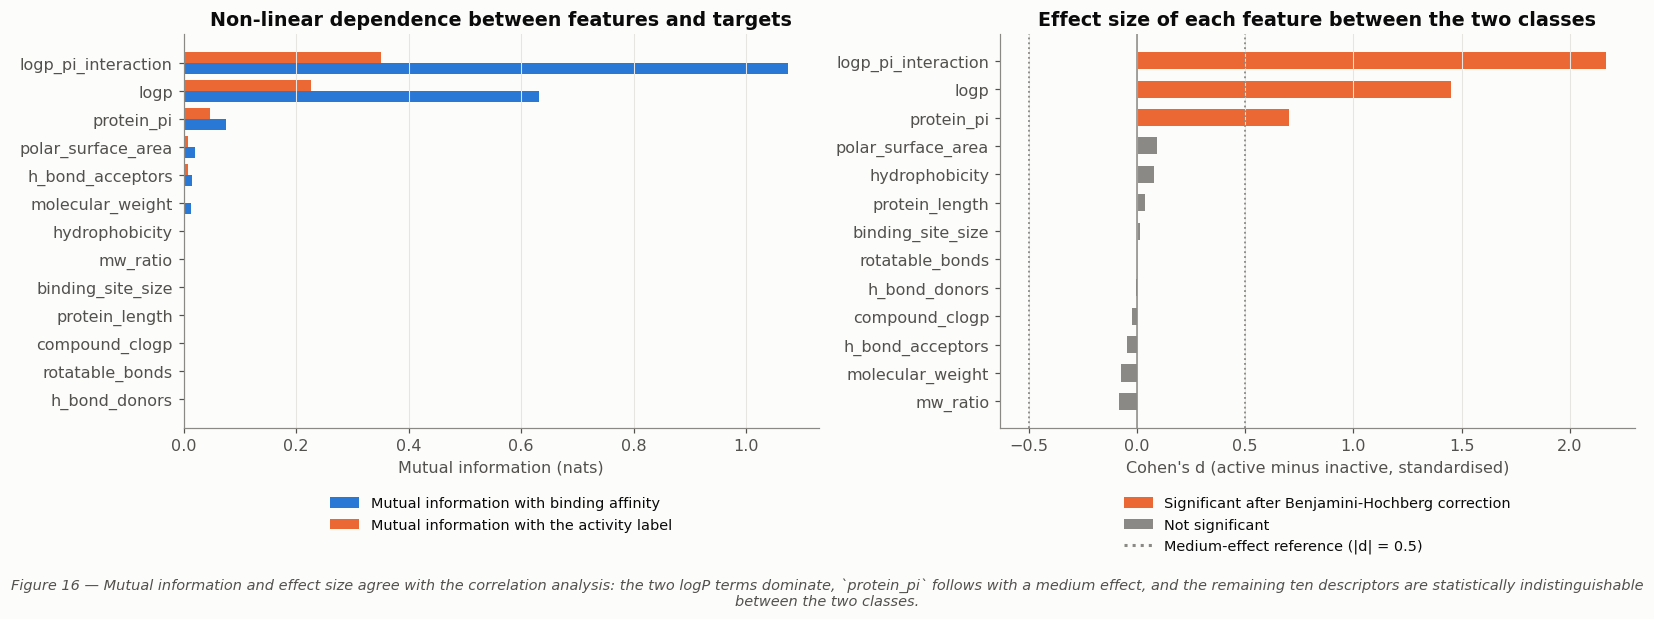

16

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))

ax = axes[0]
plot_mi = mi.sort_values("mutual_info_affinity")
y = np.arange(len(plot_mi))
ax.barh(y - 0.2, plot_mi["mutual_info_affinity"], height=0.38, color=CATEGORICAL[0],
        label="Mutual information with binding affinity")
ax.barh(y + 0.2, plot_mi["mutual_info_active"], height=0.38, color=CATEGORICAL[1],
        label="Mutual information with the activity label")
ax.set_yticks(y)
ax.set_yticklabels(plot_mi["feature"])
ax.set_xlabel("Mutual information (nats)")
ax.set_title("Non-linear dependence between features and targets")
ax.grid(axis="y", visible=False)
legend_below(ax, ncol=1, y=-0.16)

ax = axes[1]
plot_d = tests_df.sort_values("cohens_d")
colors = [CATEGORICAL[1] if sig else INK_MUTED for sig in plot_d["bh_significant"]]
bars = ax.barh(plot_d["feature"], plot_d["cohens_d"], color=colors, height=0.6)
ax.axvline(0, color=INK_MUTED, linewidth=1)
for limit in (-0.5, 0.5):
    ax.axvline(limit, color=INK_MUTED, linestyle=":", linewidth=1.2)
ax.set_xlabel("Cohen's d (active minus inactive, standardised)")
ax.set_title("Effect size of each feature between the two classes")
ax.grid(axis="y", visible=False)
legend_below(ax, [Patch(facecolor=CATEGORICAL[1]), Patch(facecolor=INK_MUTED),
                  Line2D([], [], color=INK_MUTED, linestyle=":")],
             ["Significant after Benjamini-Hochberg correction", "Not significant",
              "Medium-effect reference (|d| = 0.5)"], ncol=1, y=-0.16)

finalize(fig, "Mutual information and effect size agree with the correlation analysis: the two "
              "logP terms dominate, `protein_pi` follows with a medium effect, and the remaining "
              "ten descriptors are statistically indistinguishable between the two classes.",
         "16_feature_ranking")

**Reading Figure 16.** Mutual information is concentrated almost entirely in three features:
`logp_pi_interaction` (1.07 nats towards affinity), `logp` (0.63) and `protein_pi` (0.08). The
remaining ten sit at or below 0.02 nats, which is the level of estimation noise. Because mutual
information also detects non-monotone relationships, this rules out the hopeful assumption that
the other descriptors hide a curved signal that correlation missed.

The effect-size panel confirms it: after Benjamini-Hochberg correction exactly three features
survive — `logp_pi_interaction` (d = 2.17) and `logp` (d = 1.45), both large, and `protein_pi`
(d = 0.70), medium. **All three significant effects are positive**, so active compounds are
systematically more lipophilic and bind targets with a higher isoelectric point. The five
negative d values in the table (`mw_ratio`, `molecular_weight`, `h_bond_acceptors`,
`compound_clogp`, `h_bond_donors`) are all below |d| = 0.09 and none is significant.

---
## 11. Feature-engineering candidates validated here

Every transformation proposed for the modelling notebook is tested below *before* it is adopted,
so the feature set is justified by evidence rather than by habit.

In [38]:
# Candidate engineered features and their gain in correlation
eng = pd.DataFrame(index=df.index)
eng["logp_x_pi_exact"] = df["logp"] * df["protein_pi"]
eng["logp_x_hydrophobicity"] = df["logp"] * df["hydrophobicity"]
eng["logp_squared"] = df["logp"] ** 2
eng["mw_per_residue_exact"] = df["molecular_weight"] / df["protein_length"]
eng["tpsa_over_mw"] = df["polar_surface_area"] / df["molecular_weight"]
eng["hbd_plus_hba"] = df["h_bond_donors"] + df["h_bond_acceptors"]
eng["hba_to_hbd_ratio"] = df["h_bond_acceptors"] / (df["h_bond_donors"] + 1)
eng["clogp_minus_logp"] = df["compound_clogp"] - df["logp"]
eng["site_per_residue"] = df["binding_site_size"] / df["protein_length"]
eng["lipophilic_site_fit"] = df["logp"] * df["binding_site_size"]
eng["flexibility_index"] = df["rotatable_bonds"] / (df["molecular_weight"] / 100)
eng["lipinski_violations"] = rules["lipinski_violations"]
eng["drug_like"] = rules["drug_like"]

gain = pd.DataFrame({
    "engineered_feature": eng.columns,
    "corr_with_affinity": [eng[c].corr(df[TARGET_REG]) for c in eng.columns],
    "corr_with_active": [eng[c].corr(df[TARGET_CLF]) for c in eng.columns],
}).round(4)
gain["abs_corr"] = gain["corr_with_affinity"].abs()
gain = gain.sort_values("abs_corr", ascending=False).drop(columns="abs_corr").reset_index(drop=True)

best_raw = assoc["pearson_vs_affinity"].abs().max()
print(f"Best RAW feature correlation with binding affinity        : {best_raw:.4f}")
print(f"Best ENGINEERED feature correlation with binding affinity : "
      f"{gain['corr_with_affinity'].abs().max():.4f}")
gain

Best RAW feature correlation with binding affinity        : 0.7512
Best ENGINEERED feature correlation with binding affinity : 0.6731


,engineered_feature,corr_with_affinity,corr_with_active
0,logp_x_pi_exact,0.6731,0.6411
1,logp_x_hydrophobicity,0.5796,0.5423
2,logp_squared,0.5639,0.5750
3,lipophilic_site_fit,0.5439,0.5060
4,clogp_minus_logp,-0.4935,-0.4596
5,lipinski_violations,0.2207,0.2594
6,drug_like,-0.1451,-0.1489
7,mw_per_residue_exact,-0.0674,-0.0420
8,site_per_residue,-0.0641,-0.0276
9,flexibility_index,0.0216,0.0270


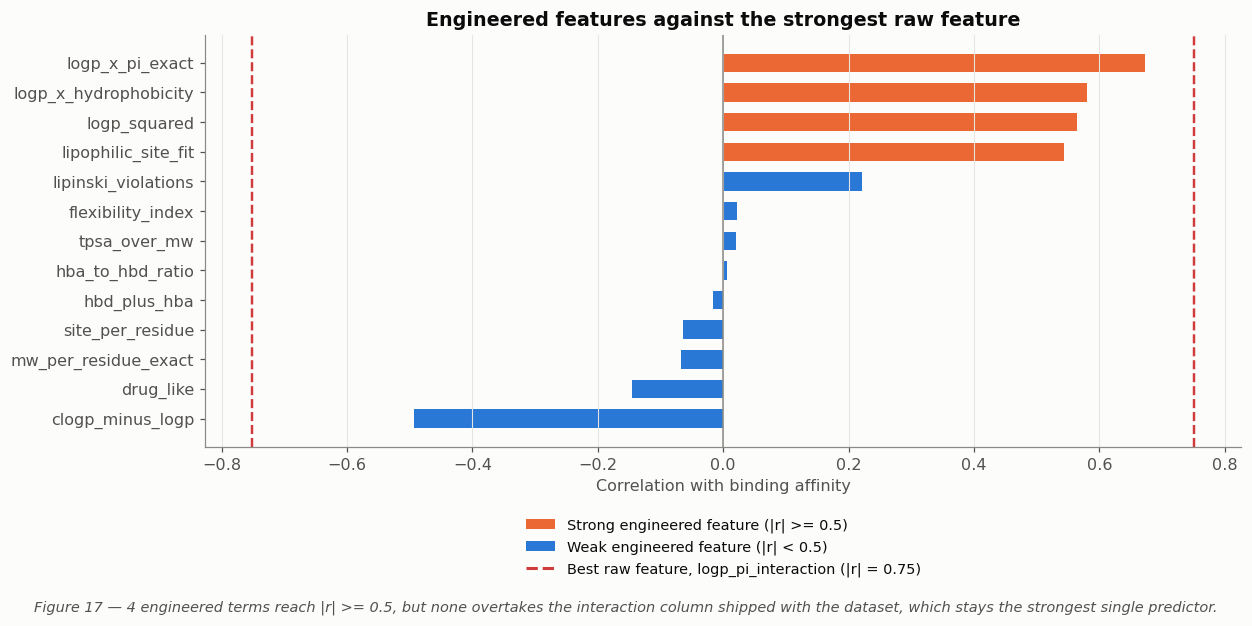

17

In [39]:
fig, ax = plt.subplots(figsize=(11.5, 5.6))
plot_gain = gain.sort_values("corr_with_affinity")
bars = ax.barh(plot_gain["engineered_feature"], plot_gain["corr_with_affinity"],
               color=[CATEGORICAL[1] if abs(v) >= 0.5 else CATEGORICAL[0]
                      for v in plot_gain["corr_with_affinity"]], height=0.62)
ax.axvline(best_raw, color=CRITICAL, linestyle="--", linewidth=1.6,
           label=f"Best raw feature (|r| = {best_raw:.2f})")
ax.axvline(-best_raw, color=CRITICAL, linestyle="--", linewidth=1.6)
ax.axvline(0, color=INK_MUTED, linewidth=1)
ax.set_xlabel("Correlation with binding affinity")
ax.set_title("Engineered features against the strongest raw feature")
ax.grid(axis="y", visible=False)
legend_below(ax, [Patch(facecolor=CATEGORICAL[1]), Patch(facecolor=CATEGORICAL[0]),
                  Line2D([], [], color=CRITICAL, linestyle="--")],
             ["Strong engineered feature (|r| >= 0.5)", "Weak engineered feature (|r| < 0.5)",
              f"Best raw feature, logp_pi_interaction (|r| = {best_raw:.2f})"], ncol=1, y=-0.16)

n_strong = int((gain["corr_with_affinity"].abs() >= 0.5).sum())

finalize(fig, f"{n_strong} engineered terms reach |r| >= 0.5, but none overtakes the interaction "
              f"column shipped with the dataset, which stays the strongest single predictor.",
         "17_engineered_features")

**Conclusion on feature engineering — and the honest version of an unexpected result.**
Recomputing the interaction term exactly (`logp x protein_pi`, r = 0.67) is **weaker** than the
shipped `logp_pi_interaction` column (r = 0.75). Section 5.4 explains why, and the explanation is
the opposite of the intuitive one: the two are *bit-identical* on about 98% of the rows, and the
gap comes entirely from the ~2% of rows where an outlier was injected into `logp` **after** the
interaction column had been computed. The shipped column is the clean record; `logp` is the
corrupted input.

Three practical consequences:

* **Keep both forms.** The shipped column preserves the clean signal on the corrupted rows; the
  recomputed term is an identical but independently derived view everywhere else.
* **Do not expect the engineered interaction to add much.** It duplicates a column the dataset
  already provides. Section 7 of `02_machine_learning_models.ipynb` measures this directly with an
  ablation instead of assuming it.
* The remaining ratio features built from hydrogen bonding, polarity and flexibility are
  individually weak, but they are cheap and give tree models extra split directions inside
  interactions. All of them are implemented in section 3 of the modelling notebook.

---
## 12. Correlation between features: is multicollinearity a risk?

In [40]:
# Strongest feature-to-feature correlations
feat_corr = df[NUMERIC_COLS].corr().abs()
pairs = (feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool))
                  .stack()
                  .rename_axis(["feature_a", "feature_b"])
                  .rename("abs_correlation")
                  .sort_values(ascending=False).head(10).reset_index())
pairs["risk"] = np.where(pairs["abs_correlation"] > 0.8, "high",
                         np.where(pairs["abs_correlation"] > 0.5, "moderate", "low"))
pairs.round(4)

,feature_a,feature_b,abs_correlation,risk
0,protein_length,mw_ratio,0.8141,high
1,logp,logp_pi_interaction,0.8071,high
2,protein_pi,logp_pi_interaction,0.4125,low
3,molecular_weight,mw_ratio,0.2798,low
4,h_bond_acceptors,protein_length,0.0439,low
5,compound_clogp,protein_pi,0.0412,low
6,logp,protein_length,0.0345,low
7,h_bond_donors,mw_ratio,0.0331,low
8,logp,h_bond_donors,0.0325,low
9,compound_clogp,hydrophobicity,0.0319,low


**Two pairs cross the 0.8 line, and both are structural.**

* `protein_length` ↔ `mw_ratio` (|r| ≈ 0.81) — `mw_ratio` *is* a molecular weight divided by
  protein length, so the denominator dominates it.
* `logp` ↔ `logp_pi_interaction` (|r| ≈ 0.81) — the interaction term is built from `logp`.

Every other pair is below 0.42. Neither pair is removed: both members carry information the other
does not (the interaction term is defined even where `logp` is missing, and `mw_ratio` normalises
for target size). The consequence is confined to **coefficient interpretation in linear models**,
where collinear predictors split the credit unstably. This is exactly why the comparison in the
modelling notebook includes Ridge, Lasso and ElasticNet next to plain linear regression, and why
feature importance is read from permutation importance rather than from raw coefficients.

---
## 13. Key findings and modelling recommendations

In [41]:
# Consolidated findings
findings = pd.DataFrame([
    ("Target leakage", "`active` equals `binding_affinity >= 7.0` for 100% of the rows",
     "Never feed `binding_affinity` to the classifier, nor `active` to the regressor"),
    ("Class imbalance", f"{df[TARGET_CLF].mean() * 100:.1f}% active, ratio "
                        f"{(df[TARGET_CLF] == 0).sum() / (df[TARGET_CLF] == 1).sum():.2f} : 1",
     "Stratify every split; report ROC-AUC, PR-AUC and MCC instead of accuracy"),
    ("Missing values", "3.0% in logp, polar_surface_area and hydrophobicity; consistent with MCAR",
     "Median imputation inside the pipeline; do not drop rows"),
    ("Outliers", "5.7% of rows beyond 3 standard deviations, plus one impossible negative polar surface area",
     "Clip to physical bounds and prefer tree models or robust losses"),
    ("Identifier column", "`compound_id` is unique for every row",
     "Drop it; encoding a perfect key invites memorisation"),
    ("High-cardinality category", "`protein_id` has 400 levels and about 5 rows per level",
     "Label-encode as requested; avoid target encoding, which would overfit on 5 rows"),
    ("Dominant signal", "logp and logp x protein_pi; every other descriptor is near zero",
     "Recompute the exact interaction term and expect a moderate performance ceiling"),
    ("Geometry", "Features are nearly orthogonal, but the classes separate along PC1, the "
                 "lipophilicity axis",
     "Skip dimensionality reduction; expect a linear boundary to already work well"),
], columns=["topic", "evidence", "action for the modelling notebook"])
findings

,topic,evidence,action for the modelling notebook
0,Target leakage,`active` equals `binding_affinity >= 7.0` for ...,Never feed `binding_affinity` to the classifie...
1,Class imbalance,"30.4% active, ratio 2.29 : 1","Stratify every split; report ROC-AUC, PR-AUC a..."
2,Missing values,"3.0% in logp, polar_surface_area and hydrophob...",Median imputation inside the pipeline; do not ...
3,Outliers,"5.7% of rows beyond 3 standard deviations, plu...",Clip to physical bounds and prefer tree models...
4,Identifier column,`compound_id` is unique for every row,Drop it; encoding a perfect key invites memori...
5,High-cardinality category,`protein_id` has 400 levels and about 5 rows p...,Label-encode as requested; avoid target encodi...
6,Dominant signal,logp and logp x protein_pi; every other descri...,Recompute the exact interaction term and expec...
7,Geometry,"Features are nearly orthogonal, but the classe...",Skip dimensionality reduction; expect a linear...


In [42]:
# Export the analysis artefacts
artefacts = {
    "overview": overview,
    "descriptive_statistics": desc.round(4),
    "missing_value_report": mcar_df,
    "outlier_report": outliers,
    "target_association": assoc,
    "statistical_tests": tests_df.round(6),
    "mutual_information": mi.round(6),
    "engineered_feature_gain": gain,
    "protein_summary": per_protein.round(4),
    "drug_likeness_summary": summary,
    "key_findings": findings,
}
for name, table in artefacts.items():
    table.to_csv(OUTPUT_DIR / f"eda_{name}.csv", index=True)

pd.DataFrame(FIGURE_INDEX).to_csv(OUTPUT_DIR / "eda_figure_index.csv", index=False)

eda_summary = {
    "rows": int(len(df)),
    "columns": int(df.shape[1]),
    "numeric_features": NUMERIC_COLS,
    "categorical_features": CATEGORICAL_COLS,
    "identifier_columns": ID_COLS,
    "target_regression": TARGET_REG,
    "target_classification": TARGET_CLF,
    "active_rate": float(df[TARGET_CLF].mean()),
    "activity_threshold_pki": float(best_t),
    "leakage_confirmed": bool(max(agreement) == 1.0),
    "columns_with_missing_values": missing.index.tolist(),
    "missing_rate": {c: float(df[c].isna().mean()) for c in missing.index},
    "recommended_engineered_features": gain["engineered_feature"].tolist(),
}
with open(OUTPUT_DIR / "eda_summary.json", "w", encoding="utf-8") as fh:
    json.dump(eda_summary, fh, indent=2)

print(f"{len(artefacts)} tables + 1 figure index + eda_summary.json written to {OUTPUT_DIR}")
print(f"{FIGURE_COUNTER['n']} figures saved as PNG to {FIGURE_DIR}")

11 tables + 1 figure index + eda_summary.json written to C:\Users\rafae.RAFAEL_NOTEBOOK\OneDrive\Documentos\Projetos_data_science_IA\kaggle\Projetos_kaggle\Drug Discovery Virtual Screening\output
17 figures saved as PNG to C:\Users\rafae.RAFAEL_NOTEBOOK\OneDrive\Documentos\Projetos_data_science_IA\kaggle\Projetos_kaggle\Drug Discovery Virtual Screening\output\figures


---
## 14. Executive summary

**The dataset in one paragraph.** 2,000 compound/protein pairs, 13 usable numerical descriptors,
one high-cardinality protein identifier and two targets that encode the same quantity. Data
quality is good: no duplicates, no constant columns, 3% missing values consistent with MCAR, and
an outlier load that is real but manageable. The predictive signal is concentrated in
lipophilicity and its interaction with the target's isoelectric point; the remaining descriptors
are essentially noise.

**The single most important result** is the leakage between the two targets. `active` is not an
independently measured label — it is `binding_affinity >= 7.0`. Any model that keeps
`binding_affinity` in the feature matrix will report perfect accuracy and be worthless. The
modelling notebook enforces the exclusion explicitly and asserts it in code.

**What to expect from modelling.** With two strong features, one moderate feature and ten weak
ones, a realistic classifier should reach roughly 0.90-0.96 ROC-AUC and a regressor should explain
a substantial but not overwhelming share of the affinity variance. Because the interaction term is
*already supplied as a column*, a linear decision boundary should be competitive with the tree
ensembles rather than trailing them — the PCA in section 9 shows the classes separating along a
single direction. Accuracy is a misleading headline metric at a 30% positive rate, so ROC-AUC,
average precision and Matthews correlation are reported instead.

*(Result, confirmed in the companion notebook: logistic regression reached 0.958 test ROC-AUC and
was selected as the simplest of the models tied at the top by cross-validation, and the four
linear regressors took the top four places in the regression benchmark.)*

**Next step →** open `02_machine_learning_models.ipynb`, which implements the feature engineering
validated here, label-encodes `protein_id`, benchmarks ten classifiers and ten regressors in a
loop, tunes the winner and saves deployment-ready pipelines to `models/`.